# Pipeline to

*   extract metadiscourse and style features for English Reddit posts and Chinese posts
*   Normalize metadiscourse features by post length
*   measure correlations between features










## Import packages

In [1]:
%%capture
# old one - openai==1.55.3
!pip install openai==2.0.0 httpx==0.27.2 --force-reinstall --quiet

In [ ]:
import os
os.kill(os.getpid(), 9)

In [1]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import sys
from google.colab import drive
import re
import json
import numpy as np
import nltk

In [3]:
import openai
from openai._client import OpenAI

In [4]:
#to access openai api keys
!pip install --quiet python-dotenv

In [5]:
## LLM API Calls - key
import dotenv

KEY_FILE_LOCATION = '/content/drive/MyDrive/API Keys/WWBP_OpenAIKey.env'
dotenv.load_dotenv(KEY_FILE_LOCATION)

True

In [6]:
# always clear this output before moving to next cell.
#!echo $OPENAI_API_KEY

In [7]:
openai.api_key = os.environ["OPENAI_API_KEY"]

## LLM Prompts to Label the Dataset In Terms of High- vs Low Context

In [8]:
def label_contextLevel_english(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates how high- versus low-context various two to three sentence-long utterances are. Answer this question: 'How much does this sentence rely on context (tone, situation, shared cultural knowledge) versus explicit wording to convey its meaning? 1 - Very low-context 2 - Low-context 3 - Moderate 4 - High-context 5 - Very high-context', unless otherwise stated. Return the output in float format."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate two to three sentence long utterances of various topics based on how high-context versus low-context they are.",
       "description": "For each utterance, answer this question: Answer this question: 'How much does this sentence rely on context (tone, situation, shared cultural knowledge) versus explicit wording to convey its meaning? 1 - Very low-context 2 - Low-context 3 - Moderate 4 - High-context 5 - Very high-context', unless otherwise stated. /
       ALWAYS FOLLOW THE RATING SCALE OF 1 (very low-context) TO 5 (very high-context). DO NOT EXPLAIN YOUR ANSWERS",
      }}
  }},
  "annotation_format": "Return the score as either 1, 2, 3, 4, or 5, in float format.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "1"
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

## LLM prompts to extract metadiscourse and style features

*   Metadiscourse features - Interactive and Interaction
*   There are two prompts below for metadiscourse features - one for English and one for Chinese.
* Style features for english



## English prompts

In [9]:
## Run 2 - metadiscourse feature labeling.
def extract_metadiscourseFeatures_english(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in two to three sentence-long utterances. You return the annotated string in JSON format after, with the format as {'annotated_text' : the annotated output }."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in two to three sentence-long utterances are.",
       "description": "Identify and label metadiscourse markers in the given text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>. DO NOT INCLUDE ANY MARKERS OUTSIDE OF THE ONES LISTED BELOW. IF THE MARKER HAS UNDERSCORES, LABEL THEM WITH UNDERSCORES, NOT DASHES, FOR EXAMPLE: IF YOU SEE A SELF-MENTION, LABEL AS word<self_mentions>. DO NOT EXPLAIN YOUR ANSWERS",
  "categories": {{
    "interactive": {{
      "": {{
        "definition": "Words that express semantic relation between main clauses.",
        "examples": ["additionally", "again", "also", "although", "as a result","at the same time", "because", "but", "consequently", "conversely", "even", "even though", "furthermore", "however", "in addition", "in the same way", "nonetheless", "on the other hand", "once", "rather", "regard", "result in", "since", "so", "still", "then", "therefore", "though", "too", "while", "yet"]
      }},
      "frame_markers": {{
        "definition": "Words that refer to discourse acts, sequences, or text stages.",
        "examples": ["to begin with", "my point is", "add", "at this point", "at this stage", "back", "begin", "finally", "first", "first of all", "goal", "in regard to", "in short", "last", "next", "my advice is", "now", "purpose", "return to", "second", "subsequently", "third", "want to", "well", "would like to"]
      }},
      "endophoric_markers": {{
        "definition": "Words that refer to information from other parts of the text.",
        "examples": ["what I mentioned before", "the above", "above", "below", "first"]
      }},
      "evidentials": {{
        "definition": "Words that refer to a source of information from other texts.",
        "examples": ["as xxx once said", "according to xxx"]
      }},
      "code_glosses": {{
        "definition": "Words that help readers grasp meanings of ideational material.",
        "examples": ["such as", "for example", "that is", "I mean", "in fact", "in other words", "indeed", "say", "this means", "which means"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "Words that withhold the writer's full commitment to a proposition.",
        "examples": ["might", "could", "I'm not sure but", "likely", "a little", "about", "almost", "apparent", "apparently", "appear", "around", "assume", "believe", "certain", "claim", "could", "doubt", "fairly", "feel", "felt", "generally", "guess", "I think", "in general", "in most cases", "in my opinion", "in my view", "know", "largely", "likely", "may", "maybe", "might", "mostly", "often", "perhaps", "possible", "possibly", "presumably", "probably", "quite", "rather", "relatively", "seems", "should", "sometimes", "somewhat", "suspect", "tend to", "typically", "unlikely", "usually", "would"]
      }},
      "boosters": {{
        "definition": "Words that emphasize force or the writer's certainty in a proposition.",
        "examples": ["definitely", "certainly", "really", "in fact", "exclamation marks (!)", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"]
      }},
      "attitude_markers": {{
        "definition": "Words that express the writer's attitude to a proposition.",
        "examples": ["I agree", "unexpectedly", "agree", "amazing", "appropriate", "disappointed", "disappointing", "even", "expected", "fortunate", "fortunately", "hopeful", "hopefully", "important", "importantly", "inappropriate", "interesting", "interestingly", "prefer", "see", "surprisingly", "understandable", "understandably", "unexpected", "unfortunate", "unfortunately", "unusual", "usual"]
      }},
      "engagement_markers": {{
        "definition": "Words that explicitly refer to or build a relationship with the reader.",
        "examples": ["consider this", "you can see that", "have to", "question marks (?)", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our", "really", "recall", "remember", "see", "should", "think about", "think of", "us", "use", "we", "you", "your"]
      }},
      "self_mentions": {{
        "definition": "Words that indicate explicit reference to the author(s).",
        "examples": ["I", "we", "our", "me", "us", "my"]
      }}
    }},
    "other": {{
      "deontic_modal_words": {{
        "definition": "Words or word phrases that express concepts of obligation, permission, and prohibition, often in the context of what a person or agent is required, allowed, or forbidden to do.",
        "examples": ["should", "must", "ought to", "may", "can", "must not", "cannot", "have to", "I suggest", "got to"]
      }},
      "adverbs_of_degree": {{
        "definition": "Words that indicate the intensity, extent, or level of an action, adjective, or another adverb",
        "examples": ["very", "extremely", "highly", "incredibly", "positively", "quite", "fairly", "somewhat", "rather", "pretty", "barely", "slightly", "almost", "enough", "so", "completely", "too"]
      }},
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "slang_and_colloquialisms": {{
        "definition": "Words or phrases commonly used in natural, highly informal, spoken conversations rather than in formal or literary writing, including ones popular in specific social groups.",
        "examples": ["going postal", "bogus", "adulting", "y'all", "what's up", "dope", "sus", "fixing to", "bruh", "feeling blue", "yeet", "bussin". "glow up", "slay", "wicked", "old fogey", "rizz", "gonna", "wanna", "brainrot", "clout", "cooked", "crash out", "delulu", "drip", "extra", "flex", "girl math", "glow-up", "GOAT", "let them cook", "irl", "mood"]
      }},
      "positive_connotations": {{
        "definition": "Words with emotional or cultural associations that goes beyond their literal meanings, with positive connotations evoke pleasant or favorable feelings and associations.",
        "examples": ["ambitious", "brave", "caring", "determined", "dazzling", "empowering", "eager", "flourishing", "generous", "meticulous", "spirited", "hopeful", "inquisitive", "heroic", "calm", "friendly", "quintessential", "vibrant", "youthful", "faithful", "eloquent"]
      }},
      "negative_connotations": {{
        "definition": "Words with unpleasant or unfavorable emotional associations or implied meanings, beyond their literal definitiona.",
        "examples": ["abrasive", "bleak", "clumsy", "dismal", "evasive", "frivolous", "gruesome", "harsh", "ignorant", "jaded", "knotty", "lethargic", "malicious", "nefarious", "obnoxious", "pernicious", "querelous", "repugnant", "sinister", "toxic", "unsettling", "vile", "warped", "xenophobic"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }},
      "place_time_svo": {{
        "definition": "Phrases that contain the setting, specifically the time and/or place, before the main subject-verb-object phrase of the text.",
        "examples": ["In New York, at noon, I ate a sandwich", "It was the dead of night in the woods when they came outside", "In the playground at noon there's going to be a fight", "Seven years ago, on my birthday, my mother gave me cake", "In Fallujah, Iraq, the U.S. Marines fought the Iraqi army", "In a land, far, far, away, there was a princess with fair hair", "Yesterday, my mother called me", "In Japan, during August, there is a festival called Tanabata"]
      }},
      "chronological_markers": {{
        "definition": "Words or phrases that establish a chronological ordering of events within the text."
        "examples": ["first", "next", "second", "afterwards", "later", "finally", "then", "before", "during", "after", "today", "tomorrow"]
      }},
      "causal_markers": {{
        "definition": "Words or phrases that establish a cause-and-effect relationship between events within the text."
        "examples": ["since", "because", "thus", "so", "as", "therefore", "due to", "as a result"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "Some guy tried to do the same thing with me<self-mentions> once!<boosters> He faked cancer for about a month, then<transitions> one day, he “had a heart attack,”<boosters> and told me<self-mentions> the hospital he was admitted into. I<self-mentions> called the hospital, and they had no record of him there. So I<self-mentions> aggressively confronted the guy, he admitted he was lying about everything, and I<self-mentions> told him he needed professional mental help. People who are THIS<boosters> crazy are scary… they don’t know what’s right vs wrong."
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  # gpt-5 only params: reasoning_effort
  # reasoning_effort="low",
  verbosity="low",
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0,
  response_format={"type": "json_object"}
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

In [10]:
## Run 2 - style feature analysis
def extract_styleFeatures_english(post, temp):
    response = openai.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "system",
                "content": "You are an AI assistant trained to evaluate and annotate utterances in social media posts based on various criteria. Rate each question on a scale from 1 (not at all) to 7 (very much), unless otherwise stated. Return the output in JSON format"
            },
            {
                "role": "user",
                "content": f'''
                {{
                    "task": "Annotate social media post utterances (defined as: 2-3 sentence long segments) based on multiple linguistic and psychological dimensions.",
                    "description": "Rate each of the following questions on a scale of 1 (not at all) to 7 (very much). Select temporal orientation as past, present, or future. If multiple orientations apply, return all that apply.\
                    ALWAYS FOLLOW THE RATING SCALE OF 1 (not at all) TO 7 (very much) EXCEPT FOR TEMPORAL ORIENTATION. GIVE A RATING FOR EVERY DIMENSION LISTED BELOW, AND ONLY THOSE. DO NOT EXPLAIN YOUR ANSWERS.\
                    ",
                    "criteria": {{
                        "informativeness": "How much does this utterance provide information or solutions?",
                        "constructive_feedback": "How much does this utterance offer constructive feedback?",
                        "author_revelation": "How much does this utterance reveal about the author?",
                        "comprehensibility": "How easy is this utterance to understand?",
                        "detail_level": "How detailed is this utterance?",
                        "explicitness": "How explicit is this utterance?",
                        "context_dependence": "How much additional context is needed to understand this utterance?",
                        "persuasiveness": "How much does this utterance attempt to persuade the reader of a point?",
                        "logical_reasoning": "How much does this utterance emphasize logical reasoning?",
                        "anecdotal_reasoning": "How much does this utterance rely on anecdotal or experiential reasoning?",
                        "right_wrong": "How much does this utterance frame actions in terms of right and wrong?",
                        "tradition": "How much does this utterance appeal to tradition or authority?",
                        "supportiveness": "How supportive is this utterance?",
                        "empathy": "How empathetic is this utterance?",
                        "status_suggestion": "How much does this utterance suggest that the people are of different status?",
                        "status_appropriateness": "How appropriate is the utterance for their status difference?",
                        "personal_choice": "How much does this utterance emphasize personal choice?",
                        "group_harmony": "How much does this utterance emphasize group harmony?",
                        "shared_responsibility": "How much does this utterance emphasize shared responsibility?",
                        "self-reliance": "How much does this utterance emphasize self-reliance?",
                        "group_wellbeing": "How much does this utterance focus on group well-being?",
                        "self_growth": "How much does this utterance emphasize self-growth?",
                        "self_responsibility": "How much does this utterance place responsibility on the individual?",
                        "ext_responsibility": "How much does this utterance place responsibility on external factors or others?",
                        "other_reliance": "How much does this utterance emphasize relying on others?",
                        "accomplish_tasks": "How much does this utterance prioritize accomplishing tasks?",
                        "implied_meaning": "How much does this utterance imply meaning rather than state it?",
                        "creative_text": "How much does this utterance use metaphors, analogies, or storytelling to convey its message?",
                        "repetitive": "How much does this utterance repeat key ideas or phrases to enhance clarity?",
                        "point_faults": "How much does this utterance avoid naming problems or pointing out faults directly?",
                        "tactful": "How tactful is this utterance?",
                        "critique": "How much does this utterance soften critique through indirect or roundabout language?",
                        "challenge": "How openly does this utterance challenge assumptions, behaviors, or norms?",
                        "conflict": "How much does this utterance downplay disagreement or conflict to maintain social harmony?",
                        "build_connection": "How much does this utterance include personal anecdotes or experiences to build connection?",
                        "orientation": "Which time period does this utterance most focus on?",
                        "vividness": "How vivid is this utterance?",
                        "expressfulness": "How expressful is this utterance?",
                        "vagueness": "How vague is this utterance?",
                        "matter_of_factness": "How matter-of-fact is this utterance?",
                        "abstractness": "How abstract is this utterance?",
                        "figurativeness": "How figurative is this utterance?",
                        "concreteness": "How concrete is this utterance?",
                        "formality": "How formal is this utterance?",
                        "conciseness": "How concise is this utterance?",
                        "verbosity": "How verbose is this utterance?",
                        "emotionality": "How emotional is this utterance?",
                        "impersonality": "How impersonal is this utterance?",
                        "politeness": "How polite is this utterance?",
                        "directness": "How direct is this utterance?",
                        "bluntness": "How blunt is this utterance?",
                        "cultural-relatedness": "How much cultural knowledge does this utterance use?",
                        "exposition": "How expository is this utterance?",
                        "narrative": "How narrative is this utterance?",
                        "narrative_mode": "How much does this utterance use a narrative mode of discourse?",
                        "expository_mode": "How much does this utterance use an expository mode of discourse?",
                        "storytelling": "How much does this utterance tell a story?",
                        "indirect": "How indirect is this utterance?",
                        "suspensefulness": "How suspenseful is this utterance?",
                        "prosociality": "How prosocial is this utterance?",
                        "clarity": "How much does this utterance focus on clarity?",
                        "engagement": "How engaging is this utterance?",
                        "showing": "How much does this utterance focus on showing rather than telling?",
                        "context-first": "How much does this utterance focus on context over information?",
                        "setting-first": "How much does this utterance show the setting (place and time) before the main information?",
                        "chronological": "How much does this utterance use chronological/temporal transitions between words?",
                        "transition_level": "How much does this utterance use transition words between parts of itself?",
                        "causal_level": "How much does this utterance use cause and effect words to connect parts of itself?"
                    }},
                    "rating_scale": "For all questions (except temporal orientation), rate on a scale of 1 (not at all) to 7(very much or a lot)."
                }},
                "text": "{post}"
               }}
                '''
            }
        ],
        # temperature=temp,
        # max_tokens=1024,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        response_format={"type": "json_object"}
    )

    output = response.choices[0].message.content.strip()
    return output

## Chinese prompts

In [11]:
def extract_metadiscourseFeatures_chinese(post, temp):
  response = openai.chat.completions.create(
  model="gpt-5-mini",
  messages=[
     {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in social media posts."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in chinese social media posts.",
       "description": "Identify and label metadiscourse markers in the given chinese text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. USE ENGLISH NAMES WHEN LABELLING MARKERS.",
  "
  "categories": {{
    "interactive": {{
      "transitions": {{
        "definition": "互动型元话语标记是帮助引导读者理解文本的词语。",
        "examples": ["一方面 … 另一方面", "此外", "除 … 之外", "另外", "进一步","并且", "而且", "不仅 … 而且(更, 还)", "既不 … 也不 …", "不论 … 还 …", "既 … 也 …", "也", "虽然(尽管) … 但是 …", "不是 … 而是 …", "并非 … 而是 …", "不过", "反之", "否则", "然而", "相反", "可是", "而", "之所以 … 是因为 …", "因为 … 所以 …", "因此", "由于", "鉴于", "只有 … 才 …"]
      }},
      "frame_markers": {{
        "definition": "框架标记语是指代话语行为、序列或文本阶段的词语。",
        "examples": ["第一 …, 第二 … .", "一 …, 二 …", "(A) …, (B) …", "① …, ② …", "首先, 其次 (接着, 再则)", "先 … 再 …", "综上所述", "总而言之", "总体来说", "总之", "从 … 的角度(视角)来看", "对 … 而言(来说)", "就 … 来讲", "从 … 讲", "在 … 的前提下", "在 … 领域(方面)", "在 … 情况下(过程中)", "当 … 时", "到目前为止", "迄今为止", "目前", "至此", "近年来", "… 年代以来", "最近", "近来", "与此同时", "同时"]
      }},
      "endophoric_markers/ 内指标记语": {{
        "definition": "内指标记语是指代文本其他部分信息的词语。",
        "examples": ["下面", "以下", "上述", "在下一节里", "以上所述"]
      }},
      "evidentials": {{
        "definition": "引证标记语是指代其他文本信息来源的词语。",
        "examples": ["据此", "根据", "按照", "由 … 看出", "… 指出", "… 表明", "由此看来", "… 论述道", "从 … 可见", "… 的研究显示"]
      }},
      "code_glosses": {{
        "definition": "解释标记语是帮助读者理解概念内容意义的词语。",
        "examples": ["定义为", "即", "… 是 …", "… 指 …", "或者(说)", "相当于", "意味着", "那就是", "意思是说", "同样", "换言之", "也可以说", "换句话说", "这就是说", "例句 …", "例如", "比如", "正如", "诸如", "譬如", "更具体地说"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "模糊限制语是减弱作者对命题的完全承诺的词语。",
        "examples": ["可能会", "也许", "很有可能的是", "似乎", "在很大 (某种, 一定)程度上", "尝试", "试图", "如果 … 就 …", "一般情况下", "一般而言", "一般", "往往", "几乎", "大致", "基本上", "恐怕", "认为"]
      }},
      "boosters": {{
        "definition": "强势语是强调命题力量或作者确定性的词语。",
        "examples": ["实际上", "事实上", "其实", "确实", "的确", "尤其(特别)是", "正是", "甚至", "当然", "着重强调", "需要指出的是", "值得一提的是", "严格来说", "很明显", "显然", "明确地", "必须", "应该"]
      }},
      "attitude_markers/ 态度标记语": {{
        "definition": "态度标记语是表达作者对命题态度的词语。",
        "examples": ["遗憾的是", "必然", "一定会", "从根本上讲", "实事求是地说", "重要的是"]
      }},
      "engagement_markers/ 介入标记语": {{
        "definition": "介入标记语是明确指代或与读者建立关系的词语。",
        "examples": ["我们", "请看", "再看", "见后", "下面分而述之(详细探讨)", "先看下面的例句", "必须", "应该"]
      }},
      "self_mentions": {{
        "definition": "自指语是加强与读者互动或建立关系的词语。",
        "examples": ["我们", "笔者", "本文作者"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets.。",
  "example": {{
    "input": "有个人曾经试图对我做过同样的事情！他假装自己得了癌症大约一个月，然后有一天，他“心脏病发作”了，并告诉我他住进了一家医院。我打电话给医院，他们那里根本没有他的记录。所以我强烈地质问了他，他承认他在撒谎，我告诉他他需要专业的心理帮助。像这样疯狂的人很可怕……他们分不清是非对错。",
    "output":"有个人曾经试图对我<self_mentions>做过同样的事情<boosters>！他假装自己得了癌症大约一个月，然后<transitions>有一天，他“心脏病发作”了<boosters>，并告诉我<self_mentions>他住进了一家医院。我<self_mentions>打电话给医院，他们那里根本没有他的记录。\
    所以我<self_mentions>强烈地质问了他，他承认他在撒谎，我<self_mentions>告诉他他需要专业的心理帮助。像这样<boosters>疯狂的人很可怕……他们分不清是非对错。"
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  # temperature=temp,
  # max_tokens=1024,
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

## Regex code to extract metadiscourse features (perhaps in combination with some LLM to get the non-regex-able features)


In [12]:
def regex_extract_metadiscourse_features(post):
  transitions_set = set(["additionally", "again", "also", "although", "as a result","at the same time", "because", "but", "consequently", "conversely", "even", "even though", "furthermore", "however", "in addition", "in the same way", "nonetheless", "on the other hand", "once", "rather", "regard", "result in", "since", "so", "still", "then", "therefore", "though", "too", "while", "yet"])
  combined_transitions = "(" + " |".join(item for item in transitions_set) + ")"

  frame_markers_set = set(["to begin with", "my point is", "add", "at this point", "at this stage", "back", "begin", "finally", "first", "first of all", "goal", "in regard to", "in short", "last", "next", "my advice is", "now", "purpose", "return to", "second", "subsequently", "third", "want to", "well", "would like to"])
  combined_frame_numbers = "(" + " |".join(item for item in frame_markers_set) + ")"

  endophoric_markers_set = set(["what I mentioned before", "the above", "above", "below", "first"])
  combined_endophoric_markers = "(" + " |".join(item for item in endophoric_markers_set) + ")"

  evidentials_set = set(["once said", "according to", "says that", "said that", "has said", "as shown in", "as noted in", "as confirmed by", "people say", "it is believed that", "it sounds like", "it looks like", "the author states", "claims", "as mentioned by", "it is said that", "they say that"])
  combined_evidentials = "(" + " |".join(item for item in evidentials_set) + ")"

  code_glosses_set = set(["such as", "for example", "namely", "to put it another way", "in simpler terms", "to clarify", "as in", "for instance", "i.e", "that is", "I mean", "in fact", "in other words", "indeed", "say", "this means", "which means", "in short", "in sum", "to summarize", "to recap", "essentially", "in effect", "including", "to illustrate", "more specifically", "more precisely"])
  combined_code_glosses = "(" + " |".join(item for item in code_glosses_set) + ")"

  hedges_set = set(["might", "could", "I\'m not sure but", "likely", "a little", "about", "almost", "apparent", "apparently", "appear", "around", "assume", "believe", "certain", "claim", "could", "doubt", "fairly", "feel", "felt", "generally", "guess", "I think", "in general", "in most cases", "in my opinion", "in my view", "know", "largely", "likely", "may", "maybe", "might", "mostly", "often", "perhaps", "possible", "possibly", "presumably", "probably", "quite", "rather", "relatively", "seems", "should", "sometimes", "somewhat", "suspect", "tend to", "typically", "unlikely", "usually", "would"])
  combined_hedges = "(" + " |".join(item for item in hedges_set) + ")"

  self_mentions_set = set(["I", "we", "I\'ve", "I\'m", "We\'ve", "our", "me", "us", "my", "mine", "myself", "ours", "ourselves"])
  combined_self_mentions = "(" + " |".join(item for item in self_mentions_set) + ")"

  boosters_set = set(["definitely", "certainly", "really", "in fact", "\!", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"])
  combined_boosters = "(" + " |".join(item for item in boosters_set) + ")"

  attitute_markers_set = set(["I agree", "unexpectedly", "agree", "amazing", "appropriate", "disappointed", "disappointing", "even", "expected", "fortunate", "fortunately", "hopeful", "hopefully", "important", "importantly", "inappropriate", "interesting", "interestingly", "prefer", "see", "surprisingly", "understandable", "understandably", "unexpected", "unfortunate", "unfortunately", "unusual", "usual"])
  combined_attitude_markers = "(" + " |".join(item for item in attitute_markers_set) + ")"

  engagement_markers_set = set(["consider this", "you can see that", "have to", "\?", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our", "really", "recall", "remember", "see", "should", "think about", "think of", "us", "use", "we", "you", "your"])
  combined_engagement_markers = "(" + " |".join(item for item in engagement_markers_set) + ")"

  deontic_modal_set = set(["should", "must", "ought to", "may", "can", "must not", "cannot", "have to", "I suggest", "got to", "necessary to", "need to", "ought to", "shall", "required to", "obligated to", "may not", "can\'t", "should not", "ought not to", "be prohibited from", "allowed to", "forbidden to", "forbidden from", "free to", "advisable to", "had better", "best to", "better to", "mandatory to"])
  combined_deontic_modals = "(" + " |".join(item for item in deontic_modal_set) + ")"

  adverbs_of_degree_set = set(["very", "extremely", "highly", "incredibly", "positively", "quite", "fairly", "somewhat", "rather", "pretty", "barely", "slightly", "almost", "enough", "so", "completely", "too", "very", "quite", "really", "absolutely", "totally", "entirely", "utterly", "hardly", "just", "nearly", "almost", "enough", "scarcely", "deeply", "severely", "immensely", "greatly", "intensely", "awfully", "tremendously", "vastly", "particularly", "incredibly", "notably", "markedly", "considerably", "moderately", "substantially", "decidedly", "surpassingly", "strongly", "overly", "exceedingly", "truly"])
  combined_adverbs_of_degree = "(" + " |".join(item for item in adverbs_of_degree_set) + ")"

  chronological_markers_set = set(["first", "next", "second", "afterwards", "later", "finally", "then", "before", "during", "after", "today", "tomorrow", "before", "after", "then", "next", "finally", "subsequently", "eventually", "meanwhile", "earlier", "later", "soon", "now", "formerly", "recently", "previously", "immediately", "afterward", "shortly", "ultimately", "initially", "instantly", "presently", "currently", "suddenly", "first", "second", "third", "last", "henceforth", "thereafter", "heretofore", "temporarily", "permanently", "increasingly", "simultaneously", "concurrently", "annually", "daily", "weekly", "monthly", "yearly", "hourly"])
  combined_chronological_markers = "(" + " |".join(item for item in chronological_markers_set) + ")"

  causal_markers_set = set(["since", "because", "thus", "so", "as", "therefore", "due to", "as a result", "because", "since", "as", "so", "therefore", "thus", "hence", "consequently", "accordingly", "resultantly", "thereupon", "wherefore", "ergo", "as a result", "as a consequence", "because of", "due to", "owing to", "thanks to", "in view of", "on account of", "for this reason", "for that reason", "in consequence", "which is why", "that is why", "leading to", "resulting in", "with the result that", "so that", "such that", "insofar as", "seeing that", "now that", "in that", "in light of", "given that", "as such"])
  combined_causal_markers = "(" + " |".join(item for item in causal_markers_set) + ")"

  positive_connotations_set = set(["ambitious", "brave", "caring", "determined", "dazzling", "empowering", "eager", "flourishing", "generous", "meticulous", "spirited", "hopeful", "inquisitive", "heroic", "calm", "friendly", "quintessential", "vibrant", "youthful", "faithful", "eloquent", "excellent", "wonderful", "fantastic", "amazing", "brilliant", "outstanding", "superb", "positive", "great", "good", "favorable", "exceptional", "admirable", "commendable", "marvelous", "impressive", "incredible", "magnificent", "terrific", "stellar", "splendid", "valuable", "successful", "effective", "efficient", "creative", "inspiring", "motivated", "resilient", "capable", "reliable", "loyal", "honest", "friendly", "kind", "generous", "supportive", "helpful", "cheerful", "enthusiastic", "happy", "joyful", "pleasant", "amused", "grateful", "respected", "worthy", "strong", "brave", "bold", "intelligent", "wise", "thoughtful", "caring", "compassionate", "humble", "noble", "diligent", "hardworking", "determined", "confident", "gracious", "charismatic", "brilliant", "articulate", "talented", "charming", "patient"])
  combined_positive_connotations = "(" + " |".join(item for item in positive_connotations_set) + ")"

  negative_connotations_set = set(["abrasive", "bleak", "clumsy", "dismal", "evasive", "frivolous", "gruesome", "harsh", "ignorant", "jaded", "knotty", "lethargic", "malicious", "nefarious", "obnoxious", "pernicious", "querelous", "repugnant", "sinister", "toxic", "unsettling", "vile", "warped", "xenophobic", "bad", "terrible", "awful", "horrible", "poor", "ugly", "unpleasant", "disgusting", "unfortunate", "unacceptable", "incompetent", "lazy", "rude", "arrogant", "selfish", "cruel", "hostile", "toxic", "annoying", "difficult", "hateful", "violent", "mean", "dishonest", "untrustworthy", "corrupt", "greedy", "cowardly", "ignorant", "stupid", "worthless", "useless", "pathetic", "hopeless", "desperate", "nasty", "bitter", "jealous", "angry", "furious", "frustrated", "depressed", "sad", "miserable", "lonely", "weak", "damaging", "dangerous", "harmful", "risky", "reckless", "failure", "problematic", "annoyed", "insecure", "manipulative", "obsessive", "needy", "controlling", "neglectful", "deceptive"])
  combined_negative_connotations = "(" + " |".join(item for item in negative_connotations_set) + ")"

  slang_and_colloquialisms_set = set(["going postal", "bogus", "adulting", "y\'all", "what\'s up", "dope", "sus", "fixing to", "bruh", "feeling blue", "yeet", "bussin", "glow up", "slay", "wicked", "old fogey", "rizz", "gonna", "wanna", "brainrot", "clout", "cooked", "crash out", "delulu", "drip", "extra", "flex", "girl math", "glow up", "GOAT", "let them cook", "irl", "mood", "cool", "lit", "sick", "dope", "fire", "chill", "vibe", "goat", "woke", "salty", "basic", "bougie", "cringe", "flex", "ghost", "stan", "simp", "sus", "yeet", "cap", "noob", "rizz", "drip", "banger", "clout", "savage", "shade", "thirsty", "lowkey", "highkey", "heck", "yikes", "meh", "lame", "broski", "fam", "dude", "bro", "hella", "kinda", "legit", "mad", "nah", "yo", "bruh", "dang", "doozy", "squad", "vibes", "balls", "props", "swole", "busted", "grind", "bomb", "grub", "hangry", "whack", "zonked"])
  combined_slang_and_colloquialisms = "(" + " |".join(item for item in slang_and_colloquialisms_set) + ")"

  # CAN USE LLMs TO GENERATE AS MANY EXAMPLES AS IT CAN THINK OF


  # check if any of the phrases in the above sets exist in the post, and if they do, then add the corresponding marker behind it
  # output_str = ""

  # post_words = post.split(" ")
  # for word in post_words:
  #   output_str += word + " "
  #   lower_word = word.lower()
  #   if lower_word in transitions_set:
  #     output_str += "<transitions> "
  #   elif lower_word in frame_markers_set:
  #     output_str += "<frame_markers> "
  #   elif lower_word in endophoric_markers_set:
  #     output_str += "<endophoric_markers> "
  #   elif lower_word in evidentials_set:
  #     output_str += "<evidentials> "
  #   elif lower_word in code_glosses_set:
  #     output_str += "<code_glosses> "
  #   elif lower_word in hedges_set:
  #     output_str += "<hedges> "
  #   elif lower_word in self_mentions_set:
  #     output_str += "<self_mentions> "
  #   else:
  #     output_str += ""

  # return output_str




  # regex attempt
  output_str = re.sub(combined_transitions, r"\1" + "<transitions> ", post, flags=re.IGNORECASE)
  output_str = re.sub(combined_frame_numbers, r"\1" + "<frame_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_endophoric_markers, r"\1" + "<endophoric_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_evidentials, r"\1" + "<evidentials> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_code_glosses, r"\1" + "<code_glosses> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_hedges, r"\1" + "<hedges> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_self_mentions, r"\1" + "<self_mentions> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_boosters, r"\1" + "<boosters> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_attitude_markers, r"\1" + "<attitude_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_engagement_markers, r"\1" + "<engagement_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_deontic_modals, r"\1" + "<deontic_modals> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_adverbs_of_degree, r"\1" + "<adverbs_of_degree> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_chronological_markers, r"\1" + "<chronological_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_causal_markers, r"\1" + "<causal_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_positive_connotations, r"\1" + "<positive_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_negative_connotations, r"\1" + "<negative_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_slang_and_colloquialisms, r"\1" + "<slang_and_colloquialisms> ", output_str, flags=re.IGNORECASE)

  return output_str


"""
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }},
      "place_time_svo": {{
        "definition": "Phrases that contain the setting, specifically the time and/or place, before the main subject-verb-object phrase of the text.",
        "examples": ["In New York, at noon, I ate a sandwich", "It was the dead of night in the woods when they came outside", "In the playground at noon there's going to be a fight", "Seven years ago, on my birthday, my mother gave me cake", "In Fallujah, Iraq, the U.S. Marines fought the Iraqi army", "In a land, far, far, away, there was a princess with fair hair", "Yesterday, my mother called me", "In Japan, during August, there is a festival called Tanabata"]
      }}
"""

<>:23: SyntaxWarning: invalid escape sequence '\!'
<>:29: SyntaxWarning: invalid escape sequence '\?'
<>:23: SyntaxWarning: invalid escape sequence '\!'
<>:29: SyntaxWarning: invalid escape sequence '\?'
/tmp/ipython-input-2610013850.py:23: SyntaxWarning: invalid escape sequence '\!'
  boosters_set = set(["definitely", "certainly", "really", "in fact", "\!", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"])
/tmp/ipython-input-2610013850.py:29: SyntaxWarning: invalid escape sequence '\?'
  engagement_markers_set = set(["consider this", "you can see that", "have to", "\?", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our",

'\n      "idioms": {{\n        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",\n        "examples": ["pay the piper", "for the birds", "pulling one\'s leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]\n      }},\n      "explicit_references": {{\n        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",\n        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky

In [13]:
def chinese_regex_metadiscourse_features(post):
  transitions_set = set(["而且", "另外", "此外", "并且", "同时", "然后", "接着", "之后", "最后", "最终", "因此", "所以", "因而", "于是", "因为", "由于", "既然", "不过", "然而", "但是", "可是", "尽管", "虽然", "相反", "与此同时", "换句话说", "也就是说", "换言之", "例如", "比如", "举例来说", "比方说", "总之", "总的来说", "简而言之", "总结来说", "综上所述", "事实上", "其实", "当然", "首先", "其次", "再次", "一方面", "另一方面", "在此期间", "与此同时", "与此同时", "从而", "为此"])
  combined_transitions = "(" + "|".join(item for item in transitions_set) + ")"

  frame_markers_set = set(["首先", "第一", "其次", "再次", "然后", "最后", "总的来说", "总之", "综上所述", "总结来说", "一般来说", "通常来说", "在……方面", "就……而言", "关于", "至于", "在此之前", "在此之后", "值得注意的是", "换句话说", "也就是说", "需要指出的是", "我们来看", "从……来看", "从这个角度来看", "下面将", "以下将", "本节讨论", "本文讨论", "本文将介绍", "本研究旨在", "本研究主要探讨", "本文主要分析", "本文首先", "本文接着", "本文最后", "简而言之"])
  combined_frame_numbers = "(" + "|".join(item for item in frame_markers_set) + ")"

  endophoric_markers_set = set(["如下", "以下", "上述", "上文", "下文", "如上所述", "如前所述", "如后所述", "如前文所提", "如本节所述", "见上文", "见下文", "详见", "如图所示", "如表所示", "如前所示", "参见", "如前所述内容", "上面提到", "下面将提到", "如上分析", "根据上述", "由此可见", "可以看出", "从上述可以看出", "正如前面提到的", "如本研究所示"])
  combined_endophoric_markers = "(" + "|".join(item for item in endophoric_markers_set) + ")"

  evidentials_set = set(["据说", "听说", "有人说", "据报道", "据资料显示", "数据显示", "研究表明", "调查显示", "证据表明", "有证据显示", "文献指出", "结果显示", "观察发现", "实验表明", "结果表明", "据统计", "据研究", "可以看出", "由此可见", "似乎", "看起来", "显然", "看来", "据称", "据悉", "据…所说", "根据…", "根据报道", "根据数据", "根据研究", "有人认为", "专家认为", "普遍认为", "一般认为", "据我们所知", "正如所见", "正如前述", "我们发现", "研究发现"])
  combined_evidentials = "(" + "|".join(item for item in evidentials_set) + ")"

  code_glosses_set = set(["也就是说", "换句话说", "换言之", "即", "就是说", "举例来说", "比如", "例如", "比方说", "像…这样的", "以…为例", "更具体地说", "更确切地说", "即是说", "亦即", "亦即是", "这就是说", "具体来说", "更进一步说", "换个角度说", "可以说", "简而言之", "就是说呢"])
  combined_code_glosses = "(" + "|".join(item for item in code_glosses_set) + ")"

  hedges_set = set(["可能", "也许", "或许", "大概", "大约", "差不多", "大致", "大体", "大体上", "大致上", "好像", "看起来", "似乎", "恐怕", "应该", "也可能", "不一定", "未必", "有点", "有些", "有可能", "基本上", "通常", "一般", "相对来说", "相当", "从某种程度上", "从某种角度看", "在一定程度上", "据说", "据了解", "据报道", "据称", "根据初步分析", "可能是因为", "貌似"])
  combined_hedges = "(" + "|".join(item for item in hedges_set) + ")"

  self_mentions_set = set(["我", "我们", "本人", "笔者", "作者", "本研究", "本论文", "本课题", "本项目", "我们认为", "我认为", "我觉得", "我们发现", "我发现", "本文认为", "本文指出", "本文分析", "本文探讨", "本文旨在", "我们提出", "我提出", "据我了解", "据我们了解", "在我看来", "我们来看", "我们希望", "我希望", "我们的观点", "我的观点"])
  combined_self_mentions = "(" + "|".join(item for item in self_mentions_set) + ")"

  boosters_set = set(["的确", "确实", "显然", "无疑", "毫无疑问", "毫无疑问地", "一定", "肯定", "绝对", "必然", "必须", "强烈", "深刻", "真正", "完全", "非常", "极其", "极为", "格外", "尤其", "特别", "明显", "当然", "总是", "始终", "始终如一", "永远", "无可置疑", "众所周知", "可以肯定", "不容置疑", "显而易见", "毋庸置疑", "可见", "足以证明", "进一步说明", "再次强调", "毫不犹豫", "千真万确"])
  combined_boosters = "(" + "|".join(item for item in boosters_set) + ")"

  attitute_markers_set = set(["可惜", "遗憾", "幸运地", "不幸地", "值得庆幸", "值得注意", "重要的是", "令人惊讶", "令人担忧", "让人遗憾", "让人欣慰", "幸好", "好在", "糟糕的是", "可喜的是", "必须承认", "显然", "毫无疑问", "诚然", "不可否认", "确实", "令人满意", "令人失望", "值得强调", "我担心", "我害怕", "我喜欢", "我希望", "我讨厌", "我遗憾", "我惊讶", "我认为重要", "我不认为", "我相信", "我担忧", "我赞成", "我反对"])
  combined_attitude_markers = "(" + "|".join(item for item in attitute_markers_set) + ")"

  engagement_markers_set = set(["过来", "怎么", "请注意", "需要指出的是", "值得注意的是", "大家知道", "众所周知", "我们可以看到", "可以看出", "你可以看到", "你会发现", "不难发现", "让我们看看", "让我们思考一下", "试想一下", "请思考", "请想一想", "要知道", "别忘了", "应该指出", "我们知道", "你知道", "正如你所见", "正如大家所知", "众所皆知", "请记住", "我们可以理解为", "换句话说", "也就是说", "我们来看看", "请看下文", "请看上文"])
  combined_engagement_markers = "(" + "|".join(item for item in engagement_markers_set) + ")"

  deontic_modal_set = set(["必须", "应该", "得", "应当", "需", "需要", "可以", "能够", "得以", "准许", "允许", "不准", "不得", "不允许", "禁止", "务必", "不可", "不可以", "应", "务须", "非得", "务必要", "必需", "必须要", "可以被允许", "被禁止", "受限于", "有义务", "有责任", "有必要"])
  combined_deontic_modals = "(" + "|".join(item for item in deontic_modal_set) + ")"

  adverbs_of_degree_set = set(["很", "非常", "特别", "极其", "极为", "相当", "十分", "格外", "异常", "稍微", "有点", "有些", "一点", "更加", "最", "较", "比较", "太", "过于", "过分", "略微", "稍许", "多少", "略", "尚", "仍然", "依然", "依旧", "几乎", "差不多", "刚刚", "刚好"])
  combined_adverbs_of_degree = "(" + "|".join(item for item in adverbs_of_degree_set) + ")"

  chronological_markers_set = set(["首先", "第一", "起初", "一开始", "最初", "然后", "接着", "接下来", "之后", "后来", "随后", "再然后", "最终", "最后", "至今", "目前", "现在", "当时", "那时", "与此同时", "在此期间", "与此同时", "此后", "从那以后", "自从", "一旦", "刚开始", "刚刚", "刚才", "以前", "之后", "后来", "已经", "将来", "未来", "以后", "很久以前", "不久之后", "紧接着"])
  combined_chronological_markers = "(" + "|".join(item for item in chronological_markers_set) + ")"

  causal_markers_set = set(["因为", "由于", "既然", "既然如此", "既然这样", "所以", "因此", "因而", "故", "以致", "以至于", "致使", "结果", "从而", "为此", "归因于", "由于此", "缘于", "基于", "鉴于", "归咎于", "导致", "引起", "促使", "造成", "因", "缘于", "出于", "故而", "于是", "因而", "进而"])
  combined_causal_markers = "(" + "|".join(item for item in causal_markers_set) + ")"

  positive_connotations_set = set(["好", "优秀", "美好", "愉快", "幸福", "成功", "光明", "出色", "卓越", "积极", "乐观", "精彩", "荣誉", "荣耀", "快乐", "满意", "友好", "温暖", "赞美", "欣赏", "富有", "丰富", "诚实", "善良", "热情", "聪明", "勇敢", "坚强", "健康", "清新", "新鲜", "幸福感", "安慰", "希望", "理想", "和平", "稳定", "繁荣", "幸运", "辉煌", "创造", "进步", "明亮", "宽容", "和谐"])
  combined_positive_connotations = "(" + "|".join(item for item in positive_connotations_set) + ")"

  negative_connotations_set = set(["坏", "糟糕", "丑陋", "悲伤", "痛苦", "失败", "黑暗", "差劲", "低劣", "消极", "悲观", "糟糕透顶", "羞耻", "耻辱", "痛苦", "不满", "敌对", "冷漠", "责备", "批评", "贫穷", "匮乏", "虚伪", "邪恶", "冷酷", "愚蠢", "胆怯", "脆弱", "生病", "污浊", "陈旧", "不幸", "沮丧", "冲突", "不稳定", "衰退", "不幸", "失败者", "丧失", "倒退", "阴暗", "狭隘", "争吵", "紧张", "仇恨"])
  combined_negative_connotations = "(" + "|".join(item for item in negative_connotations_set) + ")"

  slang_and_colloquialisms_set = set(["土豪", "给力", "萌", "skr", "打call", "666", "杠精", "表情包", "吃瓜", "小鲜肉", "老铁", "咸鱼", "宅", "撩", "尬聊", "社恐", "蓝瘦香菇", "skr", "燃", "炸裂", "炸毛", "真香", "白嫖", "冲鸭", "硬核", "佛系", "舔狗", "撕逼", "扯淡", "开挂", "划水", "打脸", "翻车", "甩锅", "暴走", "秒懂", "萌萌哒", "惊了", "碉堡", "稳", "翻盘"])
  combined_slang_and_colloquialisms = "(" + "|".join(item for item in slang_and_colloquialisms_set) + ")"

  # CAN USE LLMs TO GENERATE AS MANY EXAMPLES AS IT CAN THINK OF


  # check if any of the phrases in the above sets exist in the post, and if they do, then add the corresponding marker behind it
  # output_str = ""

  # post_words = post.split(" ")
  # for word in post_words:
  #   output_str += word + " "
  #   lower_word = word.lower()
  #   if lower_word in transitions_set:
  #     output_str += "<transitions> "
  #   elif lower_word in frame_markers_set:
  #     output_str += "<frame_markers> "
  #   elif lower_word in endophoric_markers_set:
  #     output_str += "<endophoric_markers> "
  #   elif lower_word in evidentials_set:
  #     output_str += "<evidentials> "
  #   elif lower_word in code_glosses_set:
  #     output_str += "<code_glosses> "
  #   elif lower_word in hedges_set:
  #     output_str += "<hedges> "
  #   elif lower_word in self_mentions_set:
  #     output_str += "<self_mentions> "
  #   else:
  #     output_str += ""

  # return output_str




  # regex attempt
  output_str = re.sub(combined_transitions, r"\1" + "<transitions> ", post, flags=re.IGNORECASE)
  output_str = re.sub(combined_frame_numbers, r"\1" + "<frame_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_endophoric_markers, r"\1" + "<endophoric_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_evidentials, r"\1" + "<evidentials> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_code_glosses, r"\1" + "<code_glosses> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_hedges, r"\1" + "<hedges> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_self_mentions, r"\1" + "<self_mentions> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_boosters, r"\1" + "<boosters> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_attitude_markers, r"\1" + "<attitude_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_engagement_markers, r"\1" + "<engagement_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_deontic_modals, r"\1" + "<deontic_modals> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_adverbs_of_degree, r"\1" + "<adverbs_of_degree> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_chronological_markers, r"\1" + "<chronological_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_causal_markers, r"\1" + "<causal_markers> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_positive_connotations, r"\1" + "<positive_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_negative_connotations, r"\1" + "<negative_connotations> ", output_str, flags=re.IGNORECASE)
  output_str = re.sub(combined_slang_and_colloquialisms, r"\1" + "<slang_and_colloquialisms> ", output_str, flags=re.IGNORECASE)

  return output_str


"""
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }},
      "place_time_svo": {{
        "definition": "Phrases that contain the setting, specifically the time and/or place, before the main subject-verb-object phrase of the text.",
        "examples": ["In New York, at noon, I ate a sandwich", "It was the dead of night in the woods when they came outside", "In the playground at noon there's going to be a fight", "Seven years ago, on my birthday, my mother gave me cake", "In Fallujah, Iraq, the U.S. Marines fought the Iraqi army", "In a land, far, far, away, there was a princess with fair hair", "Yesterday, my mother called me", "In Japan, during August, there is a festival called Tanabata"]
      }}
"""

'\n      "idioms": {{\n        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",\n        "examples": ["pay the piper", "for the birds", "pulling one\'s leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]\n      }},\n      "explicit_references": {{\n        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",\n        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky

##Testing prompts

In [14]:
temp=0
post = "We've known 2 people who faked cancer and many many more who did not. We should trust them. The people who actually had it were always happy to have company at the hospital and the 2 who faked it would always cancel."

In [ ]:
label_contextLevel_english(post, temp)

'3.0'

In [ ]:
extract_metadiscourseFeatures_english(post,temp)

'{\n  "annotated_text": "We<self-mentions>’ve known 2 people who faked cancer and many<boosters> many<boosters> more who did not. We<self-mentions> should<deontic_modal_words> trust them. The people who actually<boosters> had it were always<boosters> happy to have company at the hospital and the 2 who faked it would<hedges> always<boosters> cancel."\n}'

In [ ]:
regex_extract_metadiscourse_features(post)

"We've <self_mentions> known 2 people who faked cancer and many <boosters> many <boosters> more who did not. We<self_mentions>  should <deontic_modals> <engagement_markers> <hedges> trust them. The people who actually <boosters> had it we<self_mentions> re always <boosters> happy <positive_connotations> to have company at the hospital and the 2 who faked it would <hedges> always <boosters> cancel."

In [ ]:
extract_styleFeatures_english(post, temp)

'{\n  "informativeness": 5,\n  "constructive_feedback": 2,\n  "author_revelation": 6,\n  "comprehensibility": 6,\n  "detail_level": 4,\n  "explicitness": 6,\n  "context_dependence": 4,\n  "persuasiveness": 5,\n  "logical_reasoning": 4,\n  "anecdotal_reasoning": 7,\n  "right_wrong": 4,\n  "tradition": 1,\n  "supportiveness": 3,\n  "empathy": 3,\n  "status_suggestion": 2,\n  "status_appropriateness": 4,\n  "personal_choice": 3,\n  "group_harmony": 2,\n  "shared_responsibility": 2,\n  "self-reliance": 3,\n  "group_wellbeing": 3,\n  "self_growth": 2,\n  "self_responsibility": 3,\n  "ext_responsibility": 4,\n  "other_reliance": 3,\n  "accomplish_tasks": 2,\n  "implied_meaning": 3,\n  "creative_text": 2,\n  "repetitive": 3,\n  "point_faults": 2,\n  "tactful": 2,\n  "critique": 2,\n  "challenge": 5,\n  "conflict": 2,\n  "build_connection": 5,\n  "orientation": ["past"],\n  "vividness": 5,\n  "expressfulness": 5,\n  "vagueness": 2,\n  "matter_of_factness": 5,\n  "abstractness": 2,\n  "figurati

In [ ]:
temp = 0
post = "刚毕业做了客服，每天都被客户打电话过来骂。负能量爆棚，怎么调解？"

In [ ]:
extract_metadiscourseFeatures_chinese(post,temp)

'刚毕业做了客服，每天都被客户打电话过来骂。负能量爆棚，怎么<engagement_markers>调解？'

In [ ]:
chinese_regex_metadiscourse_features(post)

'刚毕业做了客服，每天都被客户打电话过来<engagement_markers> 骂。负能量爆棚，怎么<engagement_markers> 调解？'

In [ ]:
extract_styleFeatures_english(post, temp)

'{\n  "informativeness": 3,\n  "constructive_feedback": 1,\n  "author_revelation": 6,\n  "comprehensibility": 6,\n  "detail_level": 3,\n  "explicitness": 5,\n  "context_dependence": 4,\n  "persuasiveness": 1,\n  "logical_reasoning": 1,\n  "anecdotal_reasoning": 5,\n  "right_wrong": 2,\n  "tradition": 1,\n  "supportiveness": 1,\n  "empathy": 3,\n  "status_suggestion": 2,\n  "status_appropriateness": 4,\n  "personal_choice": 3,\n  "group_harmony": 2,\n  "shared_responsibility": 2,\n  "self-reliance": 4,\n  "group_wellbeing": 1,\n  "self_growth": 3,\n  "self_responsibility": 3,\n  "ext_responsibility": 4,\n  "other_reliance": 2,\n  "accomplish_tasks": 2,\n  "implied_meaning": 3,\n  "creative_text": 1,\n  "repetitive": 2,\n  "point_faults": 2,\n  "tactful": 2,\n  "critique": 2,\n  "challenge": 3,\n  "conflict": 2,\n  "build_connection": 4,\n  "orientation": ["past", "present"],\n  "vividness": 4,\n  "expressfulness": 5,\n  "vagueness": 2,\n  "matter_of_factness": 4,\n  "abstractness": 2,\n

# Functions to label high- vs low-context level

In [15]:
from tqdm import tqdm

def get_context_labels(df, temp, output_labels, message_column, message_id_column):
    """
    Processes a dataframe to label context level for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Labeling context level...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result.insert(0, label_contextLevel_english(row[message_column], temp))  # Extract features
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_labels.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    # note: might have to label like 3 times, to simulate what MTurk people will do
    # then can aggregate the score for a final label

    print("Context labeling completed.")

In [ ]:
##### CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features

# REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON THE RUN
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/indexed_english_train_4-14.csv"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
output_contextLabels_2 = list()
output_contextLabels_3 = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
# df_output_context_2 = pd.DataFrame(output_contextLabels_2)
# df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

# df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
# df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
# df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
# df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
df_output_context_1['avg_labeled_utterance'] = pd.to_numeric(df_output_context_1['labeled_utterance'])
print(df_output_context_1)

##saving output_context table
print("Saving new labeled context input table")
df_output_context_1.to_csv(output_context_filepath)

print("Finished")

Labeling context level...


Processing Posts: 100%|██████████| 1000/1000 [1:35:19<00:00,  5.72s/utterance]


Context labeling completed.
    utterance_id                                          utterance  \
0          u4326  In fact, the United States Military requires a...   
1          u2436  It's circular logic to say that it's clearly a...   
2          u3975  The sentence reads Directors as diverse as Jim...   
3          u3037  As a measure against Wikipedia: Recentism, I'd...   
4           u743  Barry, you are absolutely right. I brought thi...   
..           ...                                                ...   
995        u3873  70.122.216.176, I totally agree with everythin...   
996        u1360  Folks, NVIDIA SHIELD is a family of products. ...   
997        u4175  I have never seen an article this poor.— Prece...   
998        u3548  Andalusian here, this article is wrong. Gazpac...   
999        u3167  It's grammatically and logically correct; the ...   

    labeled_utterance  avg_labeled_utterance  
0                 1.0                    1.0  
1                 4.0    

In [ ]:
# Inputting code to compare one column's score against the aggregate to see if it shows anything
one_vs_agg = df_output_context['labeled_utterance_1'].astype('float') - df_output_context['avg_labeled_utterance'].astype(float)
one_vs_agg = one_vs_agg.apply(lambda x: abs(x))
print("column 1 mean: ")
print(one_vs_agg.mean())

two_vs_agg = df_output_context['labeled_utterance_2'].astype('float') - df_output_context['avg_labeled_utterance'].astype(float)
two_vs_agg = two_vs_agg.apply(lambda x: abs(x))
print("column 2 mean: ")
print(two_vs_agg.mean())

three_vs_agg = df_output_context['labeled_utterance_3'].astype('float') - df_output_context['avg_labeled_utterance'].astype(float)
three_vs_agg = three_vs_agg.apply(lambda x: abs(x))
print("column 3 mean: ")
print(three_vs_agg.mean())

print("agg mean: ")
print((one_vs_agg.mean() + two_vs_agg.mean() + three_vs_agg.mean()) / 3.0)

column 1 mean: 
0.04666666666666667
column 2 mean: 
0.04666666666666667
column 3 mean: 
0.04666666666666666
agg mean: 
0.04666666666666667


# Chinese Post Context Labeling

In [ ]:
##### CHINESE POST CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features


## REMEMBER TO CHANGE THE INPUT/OUTPUT DEPENDING ON WHAT RUN THIS IS
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/indexed_chinese_train_4-14.csv"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_chinese_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
output_contextLabels_2 = list()
output_contextLabels_3 = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
# get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
# df_output_context_2 = pd.DataFrame(output_contextLabels_2)
# df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
# df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

# df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
# df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
# df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
# df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
df_output_context_1['avg_labeled_utterance'] = pd.to_numeric(df_output_context_1['labeled_utterance'])

print(df_output_context_1)

##saving output_context table
print("Saving new labeled context input table")
df_output_context_1.to_csv(output_context_filepath)

print("Finished")

Labeling context level...


Processing Posts: 100%|██████████| 1000/1000 [1:59:04<00:00,  7.14s/utterance]


Context labeling completed.


ValueError: Unable to parse string "2.0
2.0" at position 577

In [ ]:
df_output_context_1.loc[577, 'labeled_utterance'] = 2
df_output_context_1.loc[579, 'labeled_utterance'] = 1
df_output_context_1['avg_labeled_utterance'] = pd.to_numeric(df_output_context_1['labeled_utterance'])


In [ ]:
df_output_context_1.to_csv(output_context_filepath)

# Japanese Post Context Labeling

In [ ]:
##### JAPANESE POST CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features


## REMEMBER TO CHANGE THE INPUT/OUTPUT DEPENDING ON WHAT RUN THIS IS
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/indexed_japanese_train_4-14.csv"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_japanese_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
output_contextLabels_2 = list()
output_contextLabels_3 = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=400)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
df_output_context_2 = pd.DataFrame(output_contextLabels_2)
df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
print(df_output_context)

##saving output_context table
print("Saving new labeled context input table")
df_output_context.to_csv(output_context_filepath)

print("Finished")

Labeling context level...


Processing Posts: 100%|██████████| 400/400 [03:47<00:00,  1.76utterance/s]


Context labeling completed.
Labeling context level...


Processing Posts: 100%|██████████| 400/400 [03:50<00:00,  1.74utterance/s]


Context labeling completed.
Labeling context level...


Processing Posts: 100%|██████████| 400/400 [03:47<00:00,  1.76utterance/s]

Context labeling completed.
    utterance_id                                          utterance  \
0             u0            （日本の新聞一覧は反対）上に同じ。 日本と海外とを区別する必要を感じないので。   
1             u1  Wetchさんに同意。 おまけに培風館の『物理学辞典』は しっかりした科学者も用いている書籍...   
2             u2  ご回答ありがとうございます。 別の疑問点が出てきましたのでもう一つ 抵抗力について 「垂直応...   
3             u3    負け犬でもそれは気になりますよ。 ご自分で自分の行動に内在する矛盾に気づいていないのですから。   
4             u4  それは独自研究です。 少なくとも1970年以前から芸能活動していた吉永小百合さんのことを「ア...   
..           ...                                                ...   
395         u395  ここに書き込んでよろしいのでしょうか？ ガイドブック等を読みましたが、いまいち、よく理解でき...   
396         u396       ご回答有難うございます。 ただお生憎ですが、私はどちらかと言えばマーチ派ですから（笑）。   
397         u397  再度案を作りました。 今回は一般向けではなく、数学的な文章にしました。 3次元多閉様体を連結...   
398         u398  このページには削除された版が複数あります。 削除に関する議論はWikipedia:削除依頼/...   
399         u399  「朝鮮」の領域は時代とともに変化しています。 例えば満洲についても同様のことが言えます。 し...   

    labeled_utterance_1 labeled_utterance_2 labeled_utterance_3  \
0                   4.0                 4.0         

# Spanish Post Context Labeling

In [ ]:
##### SPANISH POST CONTEXT LABELING #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features


## REMEMBER TO CHANGE THE INPUT/OUTPUT DEPENDING ON WHAT RUN THIS IS
input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/indexed_spanish_train_4-14.csv"

output_context_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_spanish_context_input.csv"


#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_contextLabels_1 = list()
output_contextLabels_2 = list()
output_contextLabels_3 = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=400)

## Get the 3 separate context label columns in separate lists
get_context_labels(df_input, temp, output_contextLabels_1, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_2, message_column, message_id_column)
get_context_labels(df_input, temp, output_contextLabels_3, message_column, message_id_column)

## Convert each of them to a dataframe
df_output_context_1 = pd.DataFrame(output_contextLabels_1)
df_output_context_2 = pd.DataFrame(output_contextLabels_2)
df_output_context_3 = pd.DataFrame(output_contextLabels_3)

## Rename each of the dataframe's columns, and then merge them together into one unified dataframe
df_output_context_1 = df_output_context_1.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_2 = df_output_context_2.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})
df_output_context_3 = df_output_context_3.rename(columns={0: message_id_column, 1:message_column , 2: "labeled_"+message_column})

df_output_context = pd.merge(df_output_context_1, df_output_context_2, how='inner', on=['utterance_id', 'utterance'])
df_output_context = pd.merge(df_output_context, df_output_context_3, how='inner', on=['utterance_id', 'utterance'])
df_output_context.rename(columns={'labeled_utterance_x': 'labeled_utterance_1', 'labeled_utterance_y': 'labeled_utterance_2', 'labeled_utterance': 'labeled_utterance_3'}, inplace=True)
df_output_context['avg_labeled_utterance'] = (pd.to_numeric(df_output_context['labeled_utterance_1']) + pd.to_numeric(df_output_context['labeled_utterance_2']) + pd.to_numeric(df_output_context['labeled_utterance_3'])) / 3.0
print(df_output_context)

##saving output_context table
print("Saving new labeled context input table")
df_output_context.to_csv(output_context_filepath)

print("Finished")

Labeling context level...


Processing Posts: 100%|██████████| 400/400 [03:36<00:00,  1.85utterance/s]


Context labeling completed.
Labeling context level...


Processing Posts: 100%|██████████| 400/400 [03:32<00:00,  1.88utterance/s]


Context labeling completed.
Labeling context level...


Processing Posts: 100%|██████████| 400/400 [03:33<00:00,  1.87utterance/s]

Context labeling completed.
    utterance_id                                          utterance  \
0             u0  Tengo entendido que desde 1929, y sobre todo d...   
1             u1  Aunque la candidatura se ha retirado (veremos ...   
2             u2  Parece que hay cierta confusión sobre lo que c...   
3             u3  No, los cromosomas en interfase tienen únicame...   
4             u4  Hay que especificar los títulos en español, ya...   
..           ...                                                ...   
395         u395  Eh, Eh, no tan rápido, yo también creo que es ...   
396         u396  Se puede considerar que los delfines tienen pe...   
397         u397  Sobre el párrafo en que se habla del vídeo de ...   
398         u398  En esta imagen puedes ver qué notas correspond...   
399         u399  La introducción es muy corta y debe ser un res...   

    labeled_utterance_1 labeled_utterance_2 labeled_utterance_3  \
0                   2.0                 2.0         

## Regex Function to extract metadiscourse (Only do if not doing the LLM-way!)

In [16]:
from tqdm import tqdm

def regex_get_metadiscourse_features(df, temp, output_metadiscourse, message_column, message_id_column, context_score_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting metadiscourse features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Regex-Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result.insert(0, regex_extract_metadiscourse_features(row[message_column]))  # Extract features
            result.insert(0, row[context_score_column])
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_metadiscourse.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Regex-based Feature extraction completed.")

In [17]:
from tqdm import tqdm

def chinese_regex_get_metadiscourse_features(df, temp, output_metadiscourse, message_column, message_id_column, context_score_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting metadiscourse features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Regex-Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result.insert(0, chinese_regex_metadiscourse_features(row[message_column]))  # Extract features
            result.insert(0, row[context_score_column])
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_metadiscourse.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Regex-based Feature extraction completed.")

#Functions to extract metadiscourse

In [18]:
from tqdm import tqdm

def get_metadiscourse_features(df, temp, output_metadiscourse, message_column, message_id_column, context_score_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting metadiscourse features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            output = json.loads(extract_metadiscourseFeatures_english(row[message_column], temp))
            result.insert(0, output['annotated_text'])  # Extract features
            result.insert(0, row[context_score_column])
            result.insert(0, row[message_column])
            result.insert(0, row[message_id_column])

            output_metadiscourse.append(result)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Feature extraction completed.")


In [19]:
def count_angular_bracket_features(input_text):
    """
    Count mentions of features enclosed in angular brackets within the given text.

    Args:
        input_text (str): The input string containing angular-bracketed features.

    Returns:
        dict: A dictionary with features as keys and their counts as values.
    """
    # Regular expression to find features within angular brackets
    pattern = r"<([a-zA-Z0-9_-]+)>"

    # Extract all matches
    matches = re.findall(pattern, input_text)

    # Count occurrences of each feature
    feature_counts = pd.Series(matches).value_counts().to_dict()

    return feature_counts

In [20]:
def convert_metadiscourseFeatures_to_df(df, labeled_message_column):
    """
    Process a DataFrame to count angular-bracketed features for each row in the specified column
    and transform the results into a feature-column matrix.

    Args:
        df (pd.DataFrame): The input DataFrame.
        labeled_message_column(str): The name of the column containing text inputs annotated with metadiscourse features.

    Returns:
        pd.DataFrame: A DataFrame where each feature is a column and rows correspond to input texts.
    """
    # Initialize a list to store feature counts for each row
    row_features = []

    # Iterate through the specified column
    for text in df[labeled_message_column]:
        if pd.notnull(text):
            row_features.append(count_angular_bracket_features(text))
        else:
            row_features.append({})

    # Create a DataFrame from the row features
    feature_matrix = pd.DataFrame(row_features).fillna(0).astype(int)

    # Combine with the original DataFrame
    result_df = pd.concat([df, feature_matrix], axis=1)

    return result_df


In [21]:
# normalization
# Group norms - divide features by length of post.

def group_norms(df, message_column, context_score_column):
    """
    Normalizes all numerical columns in a DataFrame by dividing them by the message length.

    Parameters:
    df (pd.DataFrame): The input DataFrame, which must contain a "message" column.

    Returns:
    pd.DataFrame: The normalized DataFrame.
    """
    if message_column not in df.columns:
        raise ValueError("The DataFrame must contain a 'message' column.")

    # Compute message length
    df = df.copy()
    df["message_length"] = df[message_column].str.len()

    # Normalize numerical columns
    numerical_cols = df.select_dtypes(include=["number"]).columns
    for col in numerical_cols:
        if col != context_score_column:
          df[col] = df[col] / df["message_length"]

    # Drop the message_length column if not needed
    df.drop(columns=["message_length"], inplace=True)

    return df


In [ ]:
##### METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

print(df_output_metadiscourse)

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

Extracting metadiscourse features...


Processing Posts: 100%|██████████| 1000/1000 [10:11:53<00:00, 36.71s/utterance]


Feature extraction completed.
    utterance_id                                          utterance  \
0          u1984  Spelunky (2008) by Derek Yu, The Binding of Is...   
1           u721  this has been the most positive interaction I ...   
2          u2503  This statement has been added, removed and had...   
3          u2963  in the English language, is this movement bett...   
4          u1411  There are cases when more information does not...   
..           ...                                                ...   
995        u3087  Not sure this will hold up GA but I don't thin...   
996        u1859  There are two different issues: 1) is the inco...   
997        u4172  I find it extremely problematic that we are im...   
998         u342  I have heard the term deathrash before and wha...   
999        u2194  If you're in high school, you've probably gott...   

     avg_labeled_utterance                                  labeled_utterance  
0                      2.0  Spelunky 

# Running Metadiscourse Feature Extraction on Chinese Dataset

In [ ]:
##### CHINESE METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_chinese_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

Extracting metadiscourse features...


Processing Posts: 100%|██████████| 1000/1000 [9:28:43<00:00, 34.12s/utterance]


Feature extraction completed.
Normalizing metadiscourse features by original post length
Saving metadiscourse feature table
Finished


# Running Metadiscourse Feature Extraction on Japanese Dataset

In [ ]:
##### JAPANESE METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_japanese_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/japanese_output_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/japanese_output_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=400)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

Extracting metadiscourse features...


Processing Posts: 100%|██████████| 400/400 [06:11<00:00,  1.08utterance/s]


Feature extraction completed.
Normalizing metadiscourse features by original post length
Saving metadiscourse feature table
Finished


# Running Metadiscourse Feature Extraction on Spanish Dataset

In [ ]:
##### SPANISH METADISCOURSE FEATURE EXTRACTION #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_spanish_context_input.csv"

## Set this variable to true for NON-NORMALISED metadiscourse features
not_normalize = False
if not_normalize:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/spanish_output_metadiscourseFeatures_notNormalized.csv"
else:
  output_metadiscourseFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/spanish_output_metadiscourseFeatures.csv"


#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"
context_score_column = "avg_labeled_utterance"

#set GPT-4o parameters.
temp = 0

#outputs
output_metadiscourseFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## RUNNING FOR A SUBSAMPLE. COMMENT BELOW LINE IF RUNNING ON COMPLETE DATASET
df_input = df_input.head(n=400)


## CHANGE THIS FUNCTION DEPENDING ON IF DOING IT VIA REGEX OR NOT
get_metadiscourse_features(df_input, temp, output_metadiscourseFeatures, message_column, message_id_column, context_score_column)
df_output_metadiscourse = pd.DataFrame(output_metadiscourseFeatures)
df_output_metadiscourse = df_output_metadiscourse.rename(columns={0: message_id_column, 1:message_column , 2: context_score_column, 3: "labeled_"+message_column})

#set labeled message column name:
labeled_message_column = "labeled_"+message_column
# extract feature counts from labeled message_column
metadicourseFeature_table = convert_metadiscourseFeatures_to_df(df_output_metadiscourse, labeled_message_column)

## normalize metadicourseFeature_table by the original post length
if not_normalize:
  print("Not Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = metadicourseFeature_table
else:
  print("Normalizing metadiscourse features by original post length")
  final_metadicourseFeature_table = group_norms(metadicourseFeature_table, message_column, context_score_column)

##saving metadiscourseFeature_table
print("Saving metadiscourse feature table")
final_metadicourseFeature_table.to_csv(output_metadiscourseFeatures_filepath)

print("Finished")

Extracting metadiscourse features...


Processing Posts: 100%|██████████| 400/400 [07:14<00:00,  1.09s/utterance]

Feature extraction completed.
Normalizing metadiscourse features by original post length
Saving metadiscourse feature table
Finished


# Functions to extract style features

In [ ]:
def get_style_features(df, temp, output_style, message_column, message_id_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Extracting style features...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result = extract_styleFeatures_english(row[message_column], temp)
            ## Adding message_id to output
            result_with_message_id = re.sub(r'(\{\s*)("informativeness")', rf'\1"message_id": "{row[message_id_column]}",\n        \2',result)

            output_style.append(result_with_message_id)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Feature extraction completed.")

In [ ]:
def convert_styleFeatures_to_df(output_styleFeatures_JSON_list):
    """
    Converts a list of JSON-formatted strings into a Pandas DataFrame.
    Handles errors for invalid JSON and missing keys.
    """
    data_rows = []

    for i, json_str in enumerate(output_styleFeatures_JSON_list):
        try:
            # Attempt to parse the JSON string
            data = json.loads(json_str)

            # Ensure "message_id" exists; if not, assign "UNKNOWN"
            if "message_id" not in data:
                print(f"Warning: Entry {i} missing 'message_id'. Assigning default.")
                data["message_id"] = "UNKNOWN"

            # Append structured row to list
            data_rows.append(data)

        except json.JSONDecodeError:
            print(f"Skipping entry {i}: Invalid JSON format.")
        except Exception as e:
            print(f"Skipping entry {i}: Unexpected error - {e}")

    # Convert collected rows into a DataFrame
    df = pd.DataFrame(data_rows)

    return df


In [ ]:
#####  EXTRACTING STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


     Unnamed: 0 utterance_id  \
492         492        u1984   
383         383         u721   
856         856        u2503   
834         834        u2963   
603         603        u1411   
..          ...          ...   
48           48        u3087   
772         772        u1859   
824         824        u4172   
207         207         u342   
969         969        u2194   

                                             utterance  labeled_utterance  \
492  Spelunky (2008) by Derek Yu, The Binding of Is...                2.0   
383  this has been the most positive interaction I ...                3.0   
856  This statement has been added, removed and had...                2.0   
834  in the English language, is this movement bett...                2.0   
603  There are cases when more information does not...                3.0   
..                                                 ...                ...   
48   Not sure this will hold up GA but I don't thin...                3.0   

Processing Posts: 100%|██████████| 1000/1000 [8:20:18<00:00, 30.02s/utterance]


Feature extraction completed.
Saving style feature table
Finished


# Extracting Style Features for Chinese Dataset

In [ ]:
#####  EXTRACTING CHINESE STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_chinese_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
# df_input = df_input.head(n=400)
df_input = df_input.sample(n=1000, random_state=21)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


     Unnamed: 0 utterance_id  \
492         492        u1984   
383         383         u721   
856         856        u2503   
834         834        u2963   
603         603        u1411   
..          ...          ...   
48           48        u3087   
772         772        u1859   
824         824        u4172   
207         207         u342   
969         969        u2194   

                                             utterance  labeled_utterance  \
492  介绍他如何提出了它，当时的人们如何反应，这件事如何影响了爱因斯坦的人生轨迹。 到“主要科學成...                3.0   
383  裁覆是說舉報內容非編輯破懷。 但如有人貼入侵權內容就是達舉報條件，不需3RR，只因侵權是很嚴...                4.0   
856  會不會有人堅持(比如說該模板的一些編輯)認為台灣是中華人民共和國的一部分導致堅持要納入？ 現...                4.0   
834  删除了这句:在他们的影响下，一些外国的朋友也跃跃欲试。。 因在新浪访问中，他们说过我们这个灵...                2.0   
603  抱歉回复晚了，首先谢谢你的意见。 不过我们在这里讨论，不用于编辑。 可以有各有各的色彩，少拿...                2.0   
..                                                 ...                ...   
48   抱歉扯到山達基，那只是個比喻罷了。 總之我想說的就只有： 毒物學是自然科學，是一翻兩瞪眼的東...                3.0   

Processing Posts: 100%|██████████| 1000/1000 [10:49:23<00:00, 38.96s/utterance]


Feature extraction completed.
Saving style feature table
Finished


# Extracting Style Features for Japanese Dataset

In [ ]:
#####  EXTRACTING JAPANESE STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_japanese_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/japanese_output_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
df_input = df_input.head(n=400)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


     Unnamed: 0 utterance_id  \
0             0           u0   
1             1           u1   
2             2           u2   
3             3           u3   
4             4           u4   
..          ...          ...   
395         395         u395   
396         396         u396   
397         397         u397   
398         398         u398   
399         399         u399   

                                             utterance  labeled_utterance_1  \
0              （日本の新聞一覧は反対）上に同じ。 日本と海外とを区別する必要を感じないので。                  4.0   
1    Wetchさんに同意。 おまけに培風館の『物理学辞典』は しっかりした科学者も用いている書籍...                  4.0   
2    ご回答ありがとうございます。 別の疑問点が出てきましたのでもう一つ 抵抗力について 「垂直応...                  2.0   
3      負け犬でもそれは気になりますよ。 ご自分で自分の行動に内在する矛盾に気づいていないのですから。                  4.0   
4    それは独自研究です。 少なくとも1970年以前から芸能活動していた吉永小百合さんのことを「ア...                  4.0   
..                                                 ...                  ...   
395  ここに書き込んでよろしいのでしょうか？ ガイドブック等を読みましたが、いまいち、よく理解でき...        

Processing Posts: 100%|██████████| 400/400 [29:40<00:00,  4.45s/utterance]

Feature extraction completed.
Saving style feature table
Finished


# Extracting Style Features for Spanish Dataset

In [ ]:
#####  EXTRACTING SPANISH STYLE FEATURES #####

## Input - Path to tables (csv here) - I used Jeffery's files to test this.
## output - dataframe with normalized metadiscourse features
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_spanish_context_input.csv"
output_styleFeatures_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/spanish_output_styleFeatures.csv"
#set column name having posts
# message_column = "detail"
# message_id_column = "message_id"
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output_styleFeatures = list()

##calling functions
df_input = pd.read_csv(input_filepath)

## running for a subsample
df_input = df_input.head(n=400)
print(df_input)

#making calls to LLM, output will be incrementaly stored in output_styleFeatures.
# If function breaks, start after the last row processed by checking len(output_styleFeatures)
get_style_features(df_input, temp, output_styleFeatures, message_column, message_id_column)

# extract style features ratings from JSON ratings to create a df
styleFeature_table = convert_styleFeatures_to_df(output_styleFeatures)

##saving styleFeature_table
print("Saving style feature table")
styleFeature_table.to_csv(output_styleFeatures_filepath)

print("Finished")


     Unnamed: 0 utterance_id  \
0             0           u0   
1             1           u1   
2             2           u2   
3             3           u3   
4             4           u4   
..          ...          ...   
395         395         u395   
396         396         u396   
397         397         u397   
398         398         u398   
399         399         u399   

                                             utterance  labeled_utterance_1  \
0    Tengo entendido que desde 1929, y sobre todo d...                  2.0   
1    Aunque la candidatura se ha retirado (veremos ...                  3.0   
2    Parece que hay cierta confusión sobre lo que c...                  2.0   
3    No, los cromosomas en interfase tienen únicame...                  2.0   
4    Hay que especificar los títulos en español, ya...                  3.0   
..                                                 ...                  ...   
395  Eh, Eh, no tan rápido, yo también creo que es ...        

Processing Posts: 100%|██████████| 400/400 [29:05<00:00,  4.36s/utterance]

Feature extraction completed.
Saving style feature table
Finished


# Statistical Comparisons (Between All Languages)

## All Languages' Utterance Length/Sentence Count Information

In [22]:
# LLM code to translate all the sentences over to English for word count/sentence count comparisons.

def translate_to_english(utterance, temp):
    response = openai.chat.completions.create(
        model="chatgpt-4o-latest",
        messages=[
            {
                "role": "system",
                "content": "You are an multilingual AI assistant trained to translate utterances, aka paragraphs containing a few sentences. Translate each utterance to English, unless otherwise stated. Return the output in JSON format"
            },
            {
                "role": "user",
                "content": f'''
                {{
                    "task": "Translate post utterances (defined as: 2-3 sentence long segments) from their original language to English.",
                    "description": "Translate each sentence to English. DO NOT EXPLAIN YOUR TRANSLATIONS, JUST TRANSLATE AND RETURN THE TRANSLATED SENTENCE.",
                }},
               }},
                    "text": "{utterance}"
               }}
                '''
            }
        ],
        temperature=temp,
        max_tokens=1024,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        response_format={"type": "json_object"}
    )

    output = response.choices[0].message.content.strip()
    return output

In [23]:
def translate_sentences(df, temp, output, message_column, message_id_column):
    """
    Processes a dataframe to extract metadiscourse features for each post.
    Uses a progress bar to display the annotation progress.
    """

    print("Translating utterances...")

    # Initialize progress bar
    with tqdm(total=len(df), desc="Processing Posts", unit=message_column) as pbar:
        for index, row in df.iterrows():
            result = list()
            result = translate_to_english(row[message_column], temp)
            ## Adding message_id to output
            result_with_message_id = re.sub(r'(\{\s*)("informativeness")', rf'\1"message_id": "{row[message_id_column]}",\n        \2',result)
            output.append(result_with_message_id)  # Save output incrementally
            pbar.update(1)  # Update progress bar

    print("Utterance translation completed.")

In [24]:
def convert_translations_to_df(translated_output_JSON_list):
    """
    Converts a list of JSON-formatted strings into a Pandas DataFrame.
    Handles errors for invalid JSON and missing keys.
    """
    data_rows = []

    for i, json_str in enumerate(translated_output_JSON_list):
        try:
            # Attempt to parse the JSON string
            data = json.loads(json_str)

            # Ensure "message_id" exists; if not, assign "UNKNOWN"
            if "message_id" not in data:
                print(f"Warning: Entry {i} missing 'message_id'. Assigning default.")
                data["message_id"] = "UNKNOWN"

            # Append structured row to list
            data_rows.append(data)

        except json.JSONDecodeError:
            print(f"Skipping entry {i}: Invalid JSON format.")
        except Exception as e:
            print(f"Skipping entry {i}: Unexpected error - {e}")

    # Convert collected rows into a DataFrame
    df = pd.DataFrame(data_rows)

    return df


In [ ]:
#####  TRANSLATING CHINESE UTTERANCES #####

## Input - Labeled Chinese Context Input
## output - dataframe with extra column
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_chinese_context_input.csv"
translated_output_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/translated_chinese_input.csv"
#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output = list()

##calling functions
df_input = pd.read_csv(input_filepath)
# df_input = df_input.head(n=10)

#making calls to LLM, output will be incrementaly stored in output.
translate_sentences(df_input, temp, output, message_column, message_id_column)

# extract translated JSON table to create a df
translated_table = convert_translations_to_df(output)
translated_table = translated_table[['translated_text']]

##saving translated_table
print("Saving translated table")
translated_table.to_csv(translated_output_filepath)

print("Finished")


Translating utterances...


Processing Posts: 100%|██████████| 1000/1000 [14:48<00:00,  1.13utterance/s]


Utterance translation completed.
Saving translated table
Finished


In [ ]:
#####  TRANSLATING JAPANESE UTTERANCES #####

## Input - Labeled Japanese Context Input
## output - dataframe with extra column
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_japanese_context_input.csv"
translated_output_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/translated_japanese_input.csv"
#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output = list()

##calling functions
df_input = pd.read_csv(input_filepath)
# df_input = df_input.head(n=10)

#making calls to LLM, output will be incrementaly stored in output.
translate_sentences(df_input, temp, output, message_column, message_id_column)

# extract translated JSON table to create a df
translated_table = convert_translations_to_df(output)
translated_table = translated_table[['translated_text']]

##saving translated_table
print("Saving translated table")
translated_table.to_csv(translated_output_filepath)

print("Finished")

Translating utterances...


Processing Posts: 100%|██████████| 400/400 [06:27<00:00,  1.03utterance/s]

Utterance translation completed.
Saving translated table
Finished


In [ ]:
#####  TRANSLATING SPANISH UTTERANCES #####

## Input - Labeled Spanish Context Input
## output - dataframe with extra column
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS

input_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_spanish_context_input.csv"
translated_output_filepath = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/translated_spanish_input.csv"
#set column name having posts
message_column = "utterance"
message_id_column = "utterance_id"

#set GPT-4o parameters.
temp = 0

#outputs
output = list()

##calling functions
df_input = pd.read_csv(input_filepath)
# df_input = df_input.head(n=10)

#making calls to LLM, output will be incrementaly stored in output.
translate_sentences(df_input, temp, output, message_column, message_id_column)

# extract translated JSON table to create a df
translated_table = convert_translations_to_df(output)
translated_table = translated_table[['translated_text']]

##saving translated_table
print("Saving translated table")
translated_table.to_csv(translated_output_filepath)

print("Finished")

Translating utterances...


Processing Posts: 100%|██████████| 400/400 [06:52<00:00,  1.03s/utterance]

Utterance translation completed.
Saving translated table
Finished


In [25]:
# Getting each language's labeled context input's average words per utterance
# and their sentence per utterance counts

from nltk.tokenize import word_tokenize

english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_context_input.csv')
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/translated_chinese_input.csv')
japanese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/translated_japanese_input.csv')
spanish_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/translated_spanish_input.csv')

english_labeled_context_input_df['utterance'] = english_labeled_context_input_df['utterance'].astype(str)
chinese_labeled_context_input_df['translated_text'] = chinese_labeled_context_input_df['translated_text'].astype(str)
japanese_labeled_context_input_df['translated_text'] = japanese_labeled_context_input_df['translated_text'].astype(str)
spanish_labeled_context_input_df['translated_text'] = spanish_labeled_context_input_df['translated_text'].astype(str)

english_avg_words_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(x.split())).mean()
print("english - avg words per utterance: ", english_avg_words_per_utterance)
english_avg_sentences_per_utterance = english_labeled_context_input_df['utterance'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("english - avg sentences per utterance: ", english_avg_sentences_per_utterance)
chinese_avg_words_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("chinese - avg words per utterance: ", chinese_avg_words_per_utterance)
chinese_avg_sentences_per_utterance = chinese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("chinese - avg sentences per utterance: ", chinese_avg_sentences_per_utterance)
japanese_avg_words_per_utterance = japanese_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("japanese - avg words per utterance: ", japanese_avg_words_per_utterance)
japanese_avg_sentences_per_utterance = japanese_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("japanese - avg sentences per utterance: ", japanese_avg_sentences_per_utterance)
spanish_avg_words_per_utterance = spanish_labeled_context_input_df['translated_text'].apply(lambda x: len(x.split())).mean()
print("spanish - avg words per utterance: ", spanish_avg_words_per_utterance)
spanish_avg_sentences_per_utterance = spanish_labeled_context_input_df['translated_text'].apply(lambda x: len(re.split(r'[.?!]', x))).mean()
print("spanish - avg sentences per utterance: ", spanish_avg_sentences_per_utterance)


english - avg words per utterance:  45.192
english - avg sentences per utterance:  3.976
chinese - avg words per utterance:  44.61
chinese - avg sentences per utterance:  3.844
japanese - avg words per utterance:  32.24
japanese - avg sentences per utterance:  3.6425
spanish - avg words per utterance:  48.3025
spanish - avg sentences per utterance:  3.9575


## All Languages' Metadiscourse Tables/Information

In [26]:
# Getting all languages' metadiscourse feature dataframes, means, and standard deviations

## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
english_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_metadiscourseFeatures.csv')
chinese_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_metadiscourseFeatures.csv')
japanese_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/japanese_output_metadiscourseFeatures.csv')
spanish_metadiscourse_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/spanish_output_metadiscourseFeatures.csv')

english_mean = english_metadiscourse_df.loc[:, ~english_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
english_std = english_metadiscourse_df.loc[:, ~english_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()
chinese_mean = chinese_metadiscourse_df.loc[:, ~chinese_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
chinese_std = chinese_metadiscourse_df.loc[:, ~chinese_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()
japanese_mean = japanese_metadiscourse_df.loc[:, ~japanese_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
japanese_std = japanese_metadiscourse_df.loc[:, ~japanese_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()
spanish_mean = spanish_metadiscourse_df.loc[:, ~spanish_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].mean()
spanish_std = spanish_metadiscourse_df.loc[:, ~spanish_metadiscourse_df.columns.isin(['Unnamed: 0', 'utterance_id', 'utterance', 'labeled_utterance'])].std()


In [28]:
english_mean

,0
avg_labeled_utterance,2.162000
engagement_markers,0.002053
hedges,0.003383
attitude_markers,0.000556
frame_markers,0.000721
boosters,0.001648
explicit_references,0.002930
transitions,0.002729
self_mentions,0.004653
causal_markers,0.001053


In [29]:
english_std

,0
avg_labeled_utterance,0.989310
engagement_markers,0.003771
hedges,0.004061
attitude_markers,0.001663
frame_markers,0.001773
boosters,0.002621
explicit_references,0.005995
transitions,0.003644
self_mentions,0.005466
causal_markers,0.002049


In [30]:
chinese_mean

,0
avg_labeled_utterance,2.050000
frame_markers,0.004584
situation_dependent_references,0.000895
chronological_markers,0.005768
explicit_references,0.005386
code_glosses,0.002181
transitions,0.012517
causal_markers,0.004141
adverbs_of_degree,0.004467
hedges,0.008440


In [31]:
chinese_std

,0
avg_labeled_utterance,1.041434
frame_markers,0.008825
situation_dependent_references,0.004350
chronological_markers,0.011931
explicit_references,0.014769
code_glosses,0.005631
transitions,0.015563
causal_markers,0.008396
adverbs_of_degree,0.008685
hedges,0.011942


## All Languages' Style Feature Tables/Information

In [27]:
# Getting all languages' style feature dataframes, means, and standard deviations

## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
english_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_styleFeatures.csv')
chinese_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_styleFeatures.csv')
japanese_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/japanese_output_styleFeatures.csv')
spanish_style_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/spanish_output_styleFeatures.csv')

english_style_mean = english_style_df.loc[:, ~english_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
english_style_std = english_style_df.loc[:, ~english_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()
chinese_style_mean = chinese_style_df.loc[:, ~chinese_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
chinese_style_std = chinese_style_df.loc[:, ~chinese_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()
japanese_style_mean = japanese_style_df.loc[:, ~japanese_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
japanese_style_std = japanese_style_df.loc[:, ~japanese_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()
spanish_style_mean = spanish_style_df.loc[:, ~spanish_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].mean()
spanish_style_std = spanish_style_df.loc[:, ~spanish_style_df.columns.isin(['Unnamed: 0', 'message_id', 'orientation'])].std()

In [33]:
english_style_mean

,0
informativeness,4.310
constructive_feedback,2.728
author_revelation,3.751
comprehensibility,6.299
detail_level,3.489
...,...
context-first,3.050
setting-first,2.070
chronological,1.790
transition_level,2.644


In [34]:
english_style_std

,0
informativeness,1.106854
constructive_feedback,1.745584
author_revelation,1.057411
comprehensibility,0.611533
detail_level,1.162424
...,...
context-first,1.181904
setting-first,1.384564
chronological,1.159847
transition_level,1.079087


In [35]:
chinese_style_mean

,0
informativeness,4.255
constructive_feedback,2.893
author_revelation,3.572
comprehensibility,6.265
detail_level,3.172
...,...
context-first,3.108
setting-first,2.095
chronological,1.785
transition_level,2.363


In [36]:
chinese_style_std

,0
informativeness,1.136339
constructive_feedback,1.819027
author_revelation,1.138469
comprehensibility,0.526357
detail_level,1.073111
...,...
context-first,1.170344
setting-first,1.406397
chronological,1.213362
transition_level,1.126277


## English-Chinese Comparison

### Comparison of Meta-Discourse Feature Frequency

In [ ]:
# english_mean = english_mean[english_mean.index.isin(chinese_mean.index)]
pooled_std = np.sqrt( (((len(english_mean) - 1) * english_std + (len(chinese_mean) - 1) * chinese_std)) / (len(english_mean) + len(chinese_mean) - 2))
cohen_d = english_mean - chinese_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
# avg_diff = english_mean - chinese_mean
# avg_diff.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/english_chinese_metadiscourse_cohen_d.xlsx')
print(cohen_d)

transitions                      -0.096285
deontic_modal_words              -0.056513
engagement_markers               -0.055975
chronological_markers            -0.055966
hedges                           -0.054894
frame_markers                    -0.051024
boosters                         -0.049210
adverbs_of_degree                -0.047439
causal_markers                   -0.041226
self_mentions                    -0.033843
code_glosses                     -0.028987
attitude_markers                 -0.027318
endophoric_markers               -0.027084
explicit_references              -0.023498
place_time_svo                   -0.022520
evidentials                      -0.022198
idioms                           -0.008692
situation_dependent_references   -0.003547
positive_connotations            -0.002696
negative_connotations            -0.002490
slang_and_colloquialisms         -0.002380
emotional_self_disclosures       -0.002102
figurative_language              -0.002020
pleonasms  

### Comparison of Style Feature Frequency

In [ ]:
english_style_mean = english_style_mean[english_style_mean.index.isin(chinese_style_mean.index)]

pooled_std = np.sqrt( (((len(english_style_mean) - 1) * english_style_std + (len(chinese_style_mean) - 1) * chinese_style_std)) / (len(english_style_mean) + len(chinese_style_mean) - 2))
cohen_d = english_style_mean - chinese_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
# avg_style_diff = english_style_mean - chinese_style_mean
# avg_style_diff.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/english_chinese_style_cohen_d.xlsx')
print(cohen_d)

cultural-relatedness   -0.625213
formality              -0.404012
conciseness            -0.295442
right_wrong            -0.201844
impersonality          -0.164058
                          ...   
showing                 0.219738
anecdotal_reasoning     0.265944
transition_level        0.267597
engagement              0.297311
detail_level            0.299836
Length: 67, dtype: float64


## English-Japanese Comparison

### Comparison of Metadiscourse Feature Frequency

In [ ]:
pooled_std = np.sqrt( (((len(english_mean) - 1) * english_std + (len(japanese_mean) - 1) * japanese_std)) / (len(english_mean) + len(japanese_mean) - 2))
cohen_d = english_mean - japanese_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
# avg_diff = english_mean - chinese_mean
# avg_diff.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/english_japanese_metadiscourse_cohen_d.xlsx')
print(cohen_d)

avg_labeled_utterance            -1.532978
hedges                           -0.077853
attitude_markers                 -0.053934
causal_markers                   -0.032728
engagement_markers               -0.029393
transitions                      -0.028095
frame_markers                    -0.024937
code_glosses                     -0.012696
chronological_markers            -0.011376
endophoric_markers               -0.010003
place_time_svo                   -0.007292
evidentials                      -0.004159
emotional_self_disclosures       -0.003778
emphasis                         -0.001259
figurative_language              -0.000424
self_mentions                    -0.000390
boosters                          0.000570
positive_connotations             0.000887
situation_dependent_references    0.001344
self-mentions                     0.005063
explicit_references               0.006095
adverbs_of_degree                 0.006927
deontic_modal_words               0.011502
emphatics  

### Comparison of Style Feature Frequency

In [ ]:
english_style_mean = english_style_mean[english_style_mean.index.isin(japanese_style_mean.index)]

pooled_std = np.sqrt( (((len(english_style_mean) - 1) * english_style_std + (len(japanese_style_mean) - 1) * japanese_style_std)) / (len(english_style_mean) + len(japanese_style_mean) - 2))
cohen_d = english_style_mean - japanese_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/english_japanese_style_cohen_d.xlsx')
print(cohen_d)

politeness           -0.842653
formality            -0.675571
tactful              -0.646505
context_dependence   -0.593545
conflict             -0.584420
                        ...   
detail_level          0.623223
challenge             0.633957
bluntness             0.681815
engagement            0.701313
vividness             0.751185
Length: 67, dtype: float64


## English-Spanish Comparison

### Comparison of Metadiscourse Feature Frequency

In [ ]:
pooled_std = np.sqrt( (((len(english_mean) - 1) * english_std + (len(spanish_mean) - 1) * spanish_std)) / (len(english_mean) + len(spanish_mean) - 2))
cohen_d = english_mean - spanish_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/english_spanish_metadiscourse_cohen_d.xlsx')
print(cohen_d)

avg_labeled_utterance            -0.920942
code_glosses                     -0.006578
transitions                      -0.005724
evidentials                      -0.003157
endophoric_markers               -0.002357
attitude_markers                 -0.002345
self_mentions                    -0.001928
positive_connotations            -0.000938
emphasis                         -0.000140
causal_markers                   -0.000135
situation_dependent_references   -0.000002
emotional_self_disclosures        0.000027
slang_and_colloquialisms          0.000715
place_time_svo                    0.000986
figurative_language               0.001136
negative_connotations             0.001303
boosters                          0.002153
chronological_markers             0.002862
frame_markers                     0.004640
explicit_references               0.007314
deontic_modal_words               0.008644
adverbs_of_degree                 0.009617
hedges                            0.013574
engagement_

### Comparison of Style Feature Frequency

In [ ]:
english_style_mean = english_style_mean[english_style_mean.index.isin(spanish_style_mean.index)]

pooled_std = np.sqrt( (((len(english_style_mean) - 1) * english_style_std + (len(spanish_style_mean) - 1) * spanish_style_std)) / (len(english_style_mean) + len(spanish_style_mean) - 2))
cohen_d = english_style_mean - spanish_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/english_spanish_style_cohen_d.xlsx')
print(cohen_d)

cultural-relatedness   -0.560986
expressfulness         -0.338566
figurativeness         -0.282065
right_wrong            -0.266292
creative_text          -0.259458
                          ...   
bluntness               0.129886
matter_of_factness      0.138000
accomplish_tasks        0.157330
directness              0.244997
impersonality           0.263048
Length: 67, dtype: float64


## Chinese-Japanese Comparison

### Comparison of Metadiscourse Feature Frequency

In [ ]:
pooled_std = np.sqrt( (((len(chinese_mean) - 1) * chinese_std + (len(japanese_mean) - 1) * japanese_std)) / (len(chinese_mean) + len(japanese_mean) - 2))
cohen_d = chinese_mean - japanese_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_japanese_metadiscourse_cohen_d.xlsx')
print(cohen_d)

avg_labeled_utterance            -0.251343
hedges                           -0.018308
attitude_markers                 -0.011513
frame_markers                    -0.008157
causal_markers                   -0.005498
positive_connotations            -0.002089
emotional_self_disclosures        0.000669
figurative_language               0.000911
emphasis                          0.001383
endophoric_markers                0.005394
place_time_svo                    0.006310
self_mentions                     0.006352
adverbs_of_degree                 0.007961
explicit_references               0.009799
evidentials                       0.010691
boosters                          0.015714
deontic_modal_words               0.019024
code_glosses                      0.019746
chronological_markers             0.021197
engagement_markers                0.024403
transitions                       0.026613
self-mentions                     0.028367
any                                    NaN
booster    

### Comparison of Style Feature Frequency

In [ ]:
chinese_style_mean = chinese_style_mean[chinese_style_mean.index.isin(japanese_style_mean.index)]

pooled_std = np.sqrt( (((len(chinese_style_mean) - 1) * chinese_style_std + (len(japanese_style_mean) - 1) * japanese_style_std)) / (len(chinese_style_mean) + len(japanese_style_mean) - 2))
cohen_d = chinese_style_mean - japanese_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_japanese_style_cohen_d.xlsx')
print(cohen_d)

politeness             -0.676081
tactful                -0.462713
context_dependence     -0.365567
point_faults           -0.325347
vagueness              -0.316597
                          ...   
logical_reasoning       0.556586
detail_level            0.558114
persuasiveness          0.569710
exposition              0.574632
cultural-relatedness    0.629820
Length: 67, dtype: float64


## Chinese-Spanish Comparison

### Comparison of Metadiscourse Feature Frequency

In [ ]:
pooled_std = np.sqrt( (((len(chinese_mean) - 1) * chinese_std + (len(spanish_mean) - 1) * spanish_std)) / (len(chinese_mean) + len(spanish_mean) - 2))
cohen_d = chinese_mean - spanish_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_spanish_metadiscourse_cohen_d.xlsx')
print(cohen_d)

positive_connotations            -0.003859
idioms                            0.000876
figurative_language               0.002430
emphasis                          0.002578
emotional_self_disclosures        0.004643
negative_connotations             0.004886
self_mentions                     0.005334
adverbs_of_degree                 0.010304
explicit_references               0.011355
evidentials                       0.013055
endophoric_markers                0.013490
place_time_svo                    0.015077
deontic_modal_words               0.017798
frame_markers                     0.017999
boosters                          0.019029
causal_markers                    0.024100
code_glosses                      0.028586
chronological_markers             0.035462
attitude_markers                  0.036325
self-mentions                     0.045715
transitions                       0.051764
hedges                            0.062932
engagement_markers                0.066054
avg_labeled

### Comparison of Style Feature Frequency

In [ ]:
chinese_style_mean = chinese_style_mean[chinese_style_mean.index.isin(spanish_style_mean.index)]

pooled_std = np.sqrt( (((len(chinese_style_mean) - 1) * chinese_style_std + (len(spanish_style_mean) - 1) * spanish_style_std)) / (len(chinese_style_mean) + len(spanish_style_mean) - 2))
cohen_d = chinese_style_mean - spanish_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_spanish_style_cohen_d.xlsx')
print(cohen_d)

expressfulness         -0.575854
author_revelation      -0.551350
engagement             -0.461119
vividness              -0.459815
emotionality           -0.428651
                          ...   
conciseness             0.276148
context_dependence      0.279279
cultural-relatedness    0.329563
formality               0.468767
impersonality           0.575248
Length: 67, dtype: float64


## Japanese-Spanish Comparison

### Comparison of Metadiscourse Feature Frequency

In [ ]:
pooled_std = np.sqrt( (((len(japanese_mean) - 1) * japanese_std + (len(spanish_mean) - 1) * spanish_std)) / (len(japanese_mean) + len(spanish_mean) - 2))
cohen_d = japanese_mean - spanish_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/japanese_spanish_metadiscourse_cohen_d.xlsx')
print(cohen_d)

deontic_modal_words              -0.004110
positive_connotations            -0.001635
self_mentions                    -0.001470
situation_dependent_references   -0.001356
explicit_references               0.000502
emphasis                          0.001130
boosters                          0.001287
adverbs_of_degree                 0.001305
figurative_language               0.001413
evidentials                       0.001446
emotional_self_disclosures        0.003800
code_glosses                      0.007191
endophoric_markers                0.008073
place_time_svo                    0.008141
chronological_markers             0.014028
self-mentions                     0.015766
transitions                       0.023206
frame_markers                     0.028519
causal_markers                    0.032382
engagement_markers                0.044223
attitude_markers                  0.052262
hedges                            0.088398
avg_labeled_utterance             0.577150
additionall

### Comparison of Style Feature Frequency

In [ ]:
japanese_style_mean = japanese_style_mean[japanese_style_mean.index.isin(spanish_style_mean.index)]

pooled_std = np.sqrt( (((len(japanese_style_mean) - 1) * japanese_style_std + (len(spanish_style_mean) - 1) * spanish_style_std)) / (len(japanese_style_mean) + len(spanish_style_mean) - 2))
cohen_d = japanese_style_mean - spanish_style_mean
cohen_d = cohen_d / pooled_std
cohen_d.sort_values(inplace=True)
cohen_d.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/japanese_spanish_style_cohen_d.xlsx')
print(cohen_d)

vividness            -0.954253
engagement           -0.847756
expressfulness       -0.786390
detail_level         -0.722282
challenge            -0.711176
                        ...   
tactful               0.490607
conciseness           0.557895
context_dependence    0.660153
formality             0.668373
politeness            0.686049
Length: 67, dtype: float64


# Correlation analysis (English)

In [ ]:
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from sklearn import metrics

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [ ]:
from google.colab import drive
# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## Loading feature tables
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
metadiscourseFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_metadiscourseFeatures.csv"
styleFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_styleFeatures.csv"

df_metadiscourse = pd.read_csv(metadiscourseFeature_Table_path, index_col=0)
df_style = pd.read_csv(styleFeature_Table_path, index_col=0)

In [ ]:
df_metadiscourse.head()

,utterance_id,utterance,avg_labeled_utterance,labeled_utterance,engagement_markers,hedges,attitude_markers,frame_markers,boosters,explicit_references,...,code_glosses,adverbs_of_degree,positive_connotations,emotional_self_disclosures,slang_and_colloquialisms,figurative_language,negative_connotations,pleonasms,hedges_deontic_modal_words,idioms
0,u1984,"Spelunky (2008) by Derek Yu, The Binding of Is...",2.0,"Spelunky (2008) by Derek Yu, The Binding of Is...",0.002825,0.002825,0.002825,0.002825,0.002825,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,u721,this has been the most positive interaction I ...,3.0,this has been the most positive interaction I<...,0.000000,0.005780,0.000000,0.000000,0.000000,0.017341,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,u2503,"This statement has been added, removed and had...",2.0,This<explicit_references> statement has been a...,0.000000,0.000000,0.000000,0.000000,0.000000,0.007246,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,u2963,"in the English language, is this movement bett...",2.0,"in the English language<place_time_svo>, is th...",0.003663,0.000000,0.000000,0.000000,0.000000,0.010989,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,u1411,There are cases when more information does not...,3.0,There are cases when more information does not...,0.000000,0.000000,0.000000,0.000000,0.005405,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_style.head()

,message_id,informativeness,constructive_feedback,author_revelation,comprehensibility,detail_level,explicitness,context_dependence,persuasiveness,logical_reasoning,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
0,u1984,2,2,4,7,2,5,5,3,3,...,1,1,6,4,2,4,4,3,2,4
1,u721,2,3,4,7,2,3,6,2,2,...,1,4,6,3,2,4,3,4,4,2
2,u2503,5,3,2,6,4,5,5,3,4,...,1,2,6,3,2,4,4,4,4,2
3,u2963,5,4,3,6,4,6,3,4,4,...,1,2,6,3,2,3,1,1,2,2
4,u1411,4,5,5,6,2,5,6,4,4,...,1,2,6,4,3,4,1,2,2,4


In [ ]:
df_metadiscourse.rename(columns={'utterance_id': 'message_id'}, inplace=True)

metadiscourseStyleFeatures_df = pd.merge(df_metadiscourse, df_style, on='message_id', how='inner')

In [ ]:
print(len(metadiscourseStyleFeatures_df), len(df_metadiscourse), len(df_style))

1000 1000 1000


In [ ]:
metadiscourseStyleFeatures_df['author_revelation']

,author_revelation
0,4
1,4
2,2
3,3
4,5
...,...
995,3
996,3
997,5
998,5


In [ ]:
print(metadiscourseStyleFeatures_df.dtypes)

message_id                object
utterance                 object
avg_labeled_utterance    float64
labeled_utterance         object
engagement_markers       float64
                          ...   
context-first              int64
setting-first              int64
chronological              int64
transition_level           int64
causal_level               int64
Length: 97, dtype: object


In [ ]:
## Computing correlations
X = metadiscourseStyleFeatures_df.select_dtypes(include=['int64', 'float64'])
X= X[X.columns[~X.columns.str.contains('nan')]]
corr = X.corr(method='pearson')

# source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(35, 35))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='RdBu', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True,cbar_kws={"shrink": .5})
#sns.clustermap(X, z_score=1, metric='cosine')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
## hierarchical clustering
corr

,avg_labeled_utterance,engagement_markers,hedges,attitude_markers,frame_markers,boosters,explicit_references,transitions,self_mentions,causal_markers,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
avg_labeled_utterance,1.000000,0.134338,0.057408,0.033144,0.030471,0.096200,0.021489,0.067625,0.049254,0.005992,...,0.043969,-0.021626,-0.335848,0.193295,-0.023304,0.032446,-0.014133,-0.011323,-0.057505,0.030688
engagement_markers,0.134338,1.000000,0.021529,-0.015587,0.033166,0.048882,-0.021998,-0.037100,0.088895,-0.026868,...,-0.059498,0.124751,-0.044846,0.141149,-0.052821,-0.036814,-0.053046,-0.059409,-0.050850,-0.047008
hedges,0.057408,0.021529,1.000000,0.022685,0.039461,-0.040273,-0.107928,0.011007,0.128047,0.003990,...,-0.040238,0.145569,-0.022958,-0.021478,-0.083809,-0.003982,-0.038410,-0.110423,0.000661,0.044813
attitude_markers,0.033144,-0.015587,0.022685,1.000000,-0.021878,0.053099,-0.025719,-0.014327,0.073505,-0.045387,...,-0.005973,0.058854,-0.073144,0.053551,0.006868,-0.032750,-0.068908,-0.027955,-0.014376,-0.075226
frame_markers,0.030471,0.033166,0.039461,-0.021878,1.000000,0.023803,-0.051347,-0.006829,0.122728,0.073874,...,0.013753,0.104029,-0.006554,-0.021716,0.003278,0.079488,0.070429,0.126827,0.119889,-0.018109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
context-first,0.032446,-0.036814,-0.003982,-0.032750,0.079488,-0.045058,-0.062311,-0.061157,0.053752,0.038208,...,0.024968,0.128280,0.010657,0.039476,0.151324,1.000000,0.674401,0.274926,0.350678,0.171675
setting-first,-0.014133,-0.053046,-0.038410,-0.068908,0.070429,-0.034375,0.033756,-0.077999,0.056015,0.004941,...,0.101829,0.031128,0.073157,0.012815,0.178292,0.674401,1.000000,0.373190,0.306130,0.069286
chronological,-0.011323,-0.059409,-0.110423,-0.027955,0.126827,-0.009444,0.012081,0.031812,0.171503,0.026745,...,0.212020,-0.021234,0.039657,-0.028895,0.204627,0.274926,0.373190,1.000000,0.500062,0.135081
transition_level,-0.057505,-0.050850,0.000661,-0.014376,0.119889,-0.038781,-0.086828,0.191290,0.078688,0.118896,...,0.117084,0.115825,0.065260,0.031667,0.193676,0.350678,0.306130,0.500062,1.000000,0.392116


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
corr.to_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run 3/feature_correlation.csv")

In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
high_context_df = corr[['avg_labeled_utterance']]
high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)
high_context_df.to_excel("/content/drive/MyDrive/High and Low Context Files/Code/Run 3/context_correlation.xlsx")
print(high_context_df)

                       avg_labeled_utterance
clarity                            -0.335848
matter_of_factness                 -0.302546
explicitness                       -0.292429
comprehensibility                  -0.277036
expository_mode                    -0.265868
...                                      ...
emotionality                        0.244273
vagueness                           0.275961
implied_meaning                     0.303895
context_dependence                  0.481277
avg_labeled_utterance               1.000000

[93 rows x 1 columns]


/tmp/ipython-input-1664515628.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
corr = pd.read_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run 3/feature_correlation.csv", index_col = 0)

# Create a copy to modify
filtered_corr_matrix = corr.copy()

thresh = 0.65

corr_pairs = filtered_corr_matrix.abs().unstack().reset_index()
# or mask = coeff < thresh

# Rename columns for clarity
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs['Feature_1'] != corr_pairs['Feature_2']]

# To avoid duplicate pairs (A,B) and (B,A), sort features alphabetically and drop duplicates
corr_pairs['Ordered_Pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset=['Ordered_Pair'])

# Get the correlation with context level for each feature
corr_pairs['Feature_1_Context_Corr'] = corr_pairs['Feature_1'].map(high_context_df['avg_labeled_utterance'])
corr_pairs['Feature_2_Context_Corr'] = corr_pairs['Feature_2'].map(high_context_df['avg_labeled_utterance'])

# Return the feature name that has the lower absolute value correlation with the context level
corr_pairs['Lower_Context_Feature'] = corr_pairs.apply(lambda row: row['Feature_1'] if abs(row['Feature_1_Context_Corr']) < abs(row['Feature_2_Context_Corr']) else
                                                       "Tie" if abs(row['Feature_1_Context_Corr']) == abs(row['Feature_2_Context_Corr']) else row['Feature_2'], axis=1)

# Sort by absolute correlation descending
most_corr_pairs = corr_pairs[corr_pairs['Correlation'] >= thresh]
most_corr_pairs = most_corr_pairs.sort_values(by='Correlation', ascending=False)
most_corr_pairs.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/ordered_correlational_pairs.xlsx')


In [ ]:
# calculate Euclidean distance after taking absolute value
abs_dist = lambda u, v: np.sqrt(((np.abs(u)-np.abs(v))**2).sum())

sns.set(font_scale=1.5)
cg = sns.clustermap(corr, row_linkage=linkage(corr, metric=abs_dist), col_linkage=linkage(corr, metric=abs_dist), figsize=(40,40), cmap='RdBu', vmin=-1, vmax=1, center= 0, annot=True, cbar_kws={"shrink": .5})
cg.ax_row_dendrogram.set_visible(False)

Output hidden; open in https://colab.research.google.com to view.

## English - Correlation Clustering/PCA

In [ ]:
english_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_context_input.csv')
X = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/output_styleFeatures.csv')
X = X.drop(['Unnamed: 0', 'message_id', 'orientation'], axis=1)

Y = english_labeled_context_input_df[['avg_labeled_utterance']]
# Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 2 else 1 if 2 <= x < 3 else 2 if 3 <= x < 4 else 3)
Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 3 else 1)
print(Y)

0      0
1      1
2      1
3      0
4      1
      ..
995    0
996    0
997    0
998    1
999    0
Name: avg_labeled_utterance, Length: 1000, dtype: int64


In [ ]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=16)
X_pca = pca.fit_transform(X_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

# note: first 11 components explain ~80.9% of total variance
# and follow Kaiser rule (>1 eigenvalue)

[8.69117919 7.97660555 5.70928965 5.00272313 3.70835852 2.53975095
 2.40863886 1.86199315 1.73638984 1.62050654 1.48278019 1.30326489
 1.22812697 1.08544465 1.05747945 1.00307704]
[0.12958937 0.11893476 0.08512807 0.07459284 0.05529329 0.03786882
 0.03591388 0.02776315 0.02589035 0.02416248 0.02210892 0.01943226
 0.01831192 0.01618447 0.01576749 0.01495633]


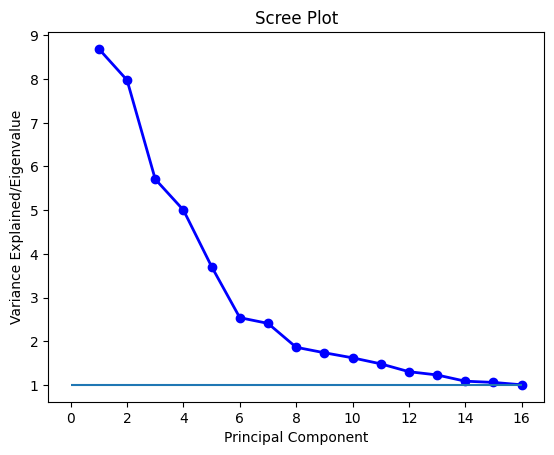

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)
pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/pca_analysis.xlsx')

                            PC1       PC2       PC3       PC4       PC5  \
informativeness       -0.064779  0.771139  0.051573  0.243689  0.199372   
constructive_feedback  0.324787  0.162222 -0.478863  0.323002  0.204519   
author_revelation      0.092766 -0.402776 -0.084732  0.435797  0.063215   
comprehensibility      0.081789  0.333251 -0.078432  0.288240 -0.331709   
detail_level          -0.180852  0.586963  0.315121  0.275626  0.298643   
...                         ...       ...       ...       ...       ...   
context-first          0.185874  0.130319  0.274535  0.156484  0.293139   
setting-first          0.079052  0.140361  0.400182  0.149439  0.105667   
chronological          0.055183  0.091241  0.620071  0.257851 -0.038126   
transition_level       0.190502  0.182428  0.358683  0.297871  0.363037   
causal_level           0.071363  0.069955  0.034883  0.377090  0.463218   

                            PC6       PC7       PC8       PC9      PC10  \
informativeness        0

In [ ]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(n_components=11, rotation='varimax')
X_fa = fa.fit_transform(X_norm)

rotated_loadings = fa.components_.T


print(fa.components_)

rotated_pca_df = pd.DataFrame(data=rotated_loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(rotated_pca_df)
rotated_pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/rotated_pca_analysis.xlsx')

# pca_df = pd.DataFrame(data=rotated_loadings,
#                       columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
#                       index=X.columns)
# print(pca_df)
# pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/pca_analysis.xlsx')

[[-1.01009821e-02 -2.49659373e-01  3.67830763e-02 -1.34426870e-02
   1.75351718e-01 -6.87820682e-02 -2.96512801e-02 -2.18324677e-01
  -1.24405720e-01  5.15079417e-01 -9.69629159e-02 -5.54284599e-02
  -9.95479082e-02 -2.86142036e-02  4.56940442e-02 -2.96419233e-02
   7.56688494e-02 -5.84249316e-02 -1.95203924e-02  1.24233948e-01
  -3.84920462e-02  1.16129126e-01  4.75301984e-02  8.70315781e-02
   1.60072685e-02  6.25455723e-03  5.09770457e-02  7.25016293e-02
   2.21565071e-02  8.71769694e-02  2.97256398e-02 -5.90214719e-02
  -1.74453555e-01 -6.65161241e-02  3.72568292e-01  3.56211018e-01
   2.26300899e-01 -3.11880387e-02 -5.22588160e-04 -8.36136960e-02
   2.95864089e-02  7.64152189e-02 -8.07099699e-02 -1.05129805e-01
   7.42016076e-02  8.27286359e-02 -1.52638623e-01  2.37199065e-02
  -1.22294801e-02 -6.46425297e-02  3.68087376e-03  6.92911511e-02
   9.89645146e-01  9.89948410e-01 -3.03318618e-02  8.67932083e-01
  -6.56201738e-03  3.40011607e-01 -7.53250199e-02  8.64202127e-04
   1.28669

In [ ]:
PC_values = np.arange(fa.components_) + 1
plt.plot(PC_values, fa.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(fa.explained_variance_))
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
supportiveness,0.791155
empathy,0.737125
personal_choice,0.529139
group_harmony,0.733694
shared_responsibility,0.572353
group_wellbeing,0.544686
tactful,0.731644
critique,0.691190
conflict,0.770046
politeness,0.697980


In [ ]:
rotated_pc1_df = rotated_pca_df[['PC1']]
rotated_pc1_df = rotated_pc1_df[(rotated_pc1_df['PC1'] <= -0.5) | (rotated_pc1_df['PC1'] >= 0.5)]
rotated_pc1_df

,PC1
anecdotal_reasoning,0.515079
narrative,0.989645
narrative_mode,0.989948
storytelling,0.867932
chronological,0.579817


In [ ]:
pc2_df = pca_df[['PC2']]
pc2_df = pc2_df[(pc2_df['PC2'] <= -0.5) | (pc2_df['PC2'] >= 0.5)]
pc2_df

,PC2
informativeness,0.771139
detail_level,0.586963
expressfulness,-0.633500
vagueness,-0.506043
matter_of_factness,0.814149
formality,0.683536
emotionality,-0.764858
impersonality,0.598592
exposition,0.728729
expository_mode,0.743022


In [ ]:
rotated_pc2_df = rotated_pca_df[['PC2']]
rotated_pc2_df = rotated_pc2_df[(rotated_pc2_df['PC2'] <= -0.5) | (rotated_pc2_df['PC2'] >= 0.5)]
rotated_pc2_df

,PC2
informativeness,-0.800550
detail_level,-0.661942
matter_of_factness,-0.587974
formality,-0.539626
exposition,-0.965707
expository_mode,-0.951498


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
anecdotal_reasoning,0.562661
narrative,0.846890
narrative_mode,0.845468
storytelling,0.778946
chronological,0.620071


In [ ]:
rotated_pc3_df = rotated_pca_df[['PC3']]
rotated_pc3_df = rotated_pc3_df[(rotated_pc3_df['PC3'] <= -0.5) | (rotated_pc3_df['PC3'] >= 0.5)]
rotated_pc3_df

,PC3
right_wrong,-0.506920
supportiveness,0.584438
tactful,0.856948
critique,0.704904
conflict,0.684641
politeness,0.848953
directness,-0.577119
bluntness,-0.850033
indirect,0.620408
prosociality,0.540124


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.5) | (pc4_df['PC4'] >= 0.5)]
pc4_df

,PC4


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.5) | (pc5_df['PC5'] >= 0.5)]
pc5_df

,PC5
logical_reasoning,0.599618


In [ ]:
pc6_df = pca_df[['PC6']]
pc6_df = pc6_df[(pc6_df['PC6'] <= -0.5) | (pc6_df['PC6'] >= 0.5)]
pc6_df

,PC6
creative_text,0.539240
figurativeness,0.540026


In [ ]:
pc7_df = pca_df[['PC7']]
pc7_df = pc7_df[(pc7_df['PC7'] <= -0.3) | (pc7_df['PC7'] >= 0.3)]
pc7_df

,PC7
author_revelation,-0.329454
comprehensibility,-0.345387
status_suggestion,0.444194
status_appropriateness,0.418616
shared_responsibility,0.357136
other_reliance,0.361973
impersonality,0.365420


In [ ]:
pc8_df = pca_df[['PC8']]
pc8_df = pc8_df[(pc8_df['PC8'] <= -0.3) | (pc8_df['PC8'] >= 0.3)]
pc8_df

,PC8
self-reliance,0.419523
creative_text,0.392854
figurativeness,0.424764
context-first,-0.367343
setting-first,-0.398201


In [ ]:
pc9_df = pca_df[['PC9']]
pc9_df = pc9_df[(pc9_df['PC9'] <= -0.3) | (pc9_df['PC9'] >= 0.3)]
pc9_df

,PC9
tradition,0.400070
ext_responsibility,-0.325478


In [ ]:
pc10_df = pca_df[['PC10']]
pc10_df = pc10_df[(pc10_df['PC10'] <= -0.3) | (pc10_df['PC10'] >= 0.3)]
pc10_df

,PC10
accomplish_tasks,-0.300849
cultural-relatedness,0.408132


In [ ]:
pc11_df = pca_df[['PC11']]
pc11_df = pc11_df[(pc11_df['PC11'] <= -0.2) | (pc11_df['PC11'] >= 0.2)]
pc11_df

,PC11
constructive_feedback,0.219043
status_suggestion,-0.282374
status_appropriateness,-0.217411
self_growth,-0.248559
accomplish_tasks,0.247416
abstractness,-0.214898
formality,-0.249507
verbosity,-0.229131
cultural-relatedness,0.307392


t-SNE reduced data shape: (400, 2)


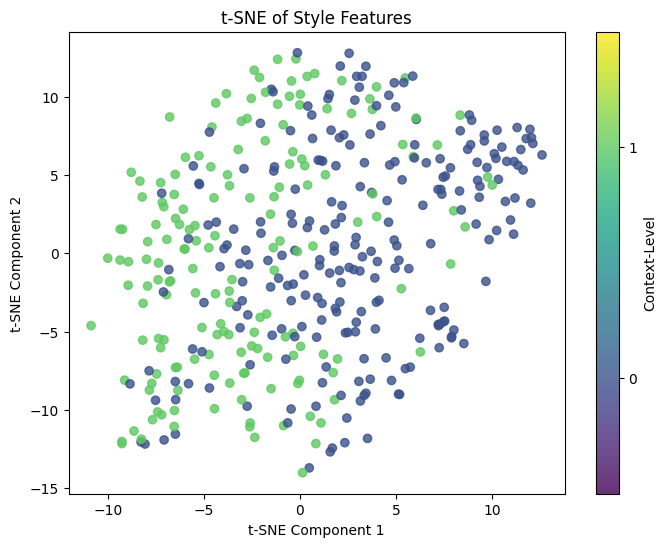

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(X_norm)

print(f"t-SNE reduced data shape: {X_tsne.shape}")

# 6. Visualization of t-SNE results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=Y, cmap='viridis', alpha=0.8)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of Style Features')
# target_names = ['Very Low-Context', 'Low-Context', 'High-Context', 'Very High-Context']
target_names = ['Low-Context', 'High-Context']
plt.colorbar(scatter, ticks=range(len(target_names)), label='Context-Level')
plt.clim(-0.5, len(target_names) - 0.5) # Adjust colorbar limits to center ticks
plt.show()

In [ ]:
import plotly.express as px

fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=)
fig.update_layout(
    title="PCA visualization of Customer Churn dataset",
    xaxis_title="First Principal Component",
    yaxis_title="Second Principal Component",
)
fig.show()

ValueError: Data must be 1-dimensional, got ndarray of shape (320, 1) instead

In [ ]:
# create a train/test split
X_train, X_test, y_train, y_test = train_test_split(X_norm, Y, test_size=0.2, random_state=7)

# Correlation Analysis (Chinese)

In [ ]:
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage
from sklearn import metrics

%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 100

In [ ]:
## Loading Chinese feature tables
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_metadiscourseFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_metadiscourseFeatures.csv"
chinese_styleFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_styleFeatures.csv"

chinese_df_metadiscourse = pd.read_csv(chinese_metadiscourseFeature_Table_path, index_col=0)
chinese_df_style = pd.read_csv(chinese_styleFeature_Table_path, index_col=0)

In [ ]:
chinese_df_metadiscourse.rename(columns={'utterance_id': 'message_id'}, inplace=True)

chinese_metadiscourseStyleFeatures_df = pd.merge(chinese_df_metadiscourse, chinese_df_style, on='message_id', how='inner')

In [ ]:
print(chinese_metadiscourseStyleFeatures_df.dtypes)

message_id                object
utterance                 object
avg_labeled_utterance    float64
labeled_utterance         object
frame_markers            float64
                          ...   
context-first              int64
setting-first              int64
chronological              int64
transition_level           int64
causal_level               int64
Length: 104, dtype: object


In [ ]:
## Computing correlations for chinese_dataset
X = chinese_metadiscourseStyleFeatures_df.select_dtypes(include=['int64', 'float64'])
X= X[X.columns[~X.columns.str.contains('nan')]]
corr = X.corr(method='pearson')

# source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(35, 35))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='RdBu', vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, annot=True,cbar_kws={"shrink": .5})

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
## hierarchical clustering
corr

,avg_labeled_utterance,frame_markers,situation_dependent_references,chronological_markers,explicit_references,code_glosses,transitions,causal_markers,adverbs_of_degree,hedges,...,suspensefulness,prosociality,clarity,engagement,showing,context-first,setting-first,chronological,transition_level,causal_level
avg_labeled_utterance,1.000000,-0.016271,0.005216,-0.010887,0.066657,-0.015314,-0.008440,0.061322,-0.003494,0.005349,...,0.031633,-0.129845,-0.313402,0.289747,0.121242,0.036629,0.011106,-0.058818,-0.085469,-0.018537
frame_markers,-0.016271,1.000000,-0.009333,0.045166,-0.028905,0.000244,-0.069849,0.002108,-0.049893,-0.072966,...,0.017138,0.060222,-0.005959,-0.059055,-0.050756,0.032218,0.069579,0.077020,0.107713,-0.002512
situation_dependent_references,0.005216,-0.009333,1.000000,-0.004157,0.069454,-0.027172,-0.063806,-0.045460,-0.014412,0.033720,...,0.022984,-0.031560,-0.041640,0.056153,0.034190,-0.011774,0.003669,-0.017322,-0.033518,-0.036896
chronological_markers,-0.010887,0.045166,-0.004157,1.000000,0.000366,-0.089093,-0.110181,-0.008855,-0.029320,-0.074326,...,0.047521,-0.044822,0.018106,-0.046557,-0.028570,0.037224,0.128498,0.374323,0.173901,-0.017338
explicit_references,0.066657,-0.028905,0.069454,0.000366,1.000000,-0.020649,-0.085696,-0.076870,0.026241,-0.056205,...,0.070858,-0.084139,-0.006259,0.039037,-0.046715,-0.071842,0.008630,-0.019919,-0.067537,-0.107716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
context-first,0.036629,0.032218,-0.011774,0.037224,-0.071842,-0.045019,-0.041826,0.122529,-0.010304,0.032618,...,-0.026000,0.144512,-0.045351,0.006803,0.100093,1.000000,0.663945,0.337805,0.375753,0.335351
setting-first,0.011106,0.069579,0.003669,0.128498,0.008630,-0.059634,-0.078922,0.069687,-0.021514,-0.017462,...,-0.004046,0.045219,0.003785,-0.031347,0.070586,0.663945,1.000000,0.447232,0.336522,0.212598
chronological,-0.058818,0.077020,-0.017322,0.374323,-0.019919,-0.075945,-0.061750,0.097794,-0.042898,-0.049084,...,0.050106,-0.001212,0.043025,-0.089199,0.090158,0.337805,0.447232,1.000000,0.580161,0.261950
transition_level,-0.085469,0.107713,-0.033518,0.173901,-0.067537,-0.034131,0.066694,0.174553,-0.024046,0.005857,...,0.044514,0.176185,0.066028,0.009383,0.090414,0.375753,0.336522,0.580161,1.000000,0.478111


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
corr.to_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_feature_correlation.csv")

In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_high_context_df = corr[['avg_labeled_utterance']]
chinese_high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)
chinese_high_context_df.to_excel("/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_context_correlation.xlsx")
print(chinese_high_context_df)

                       avg_labeled_utterance
matter_of_factness                 -0.407004
informativeness                    -0.349972
comprehensibility                  -0.343761
expository_mode                    -0.315404
clarity                            -0.313402
...                                      ...
engagement                          0.289747
emotionality                        0.295571
implied_meaning                     0.414622
context_dependence                  0.439996
avg_labeled_utterance               1.000000

[100 rows x 1 columns]


/tmp/ipython-input-3282004948.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chinese_high_context_df.sort_values(by='avg_labeled_utterance', inplace=True)


In [ ]:
## REMEMBER TO CHANGE THE INPUT/OUTPUT FILEPATH DEPENDING ON WHAT RUN IT IS
chinese_corr = pd.read_csv("/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_feature_correlation.csv", index_col = 0)

# Create a copy to modify
chinese_filtered_corr_matrix = chinese_corr.copy()

thresh = 0.65

chinese_corr_pairs = chinese_filtered_corr_matrix.abs().unstack().reset_index()
# or mask = coeff < thresh

# Rename columns for clarity
chinese_corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self correlations
chinese_corr_pairs = chinese_corr_pairs[chinese_corr_pairs['Feature_1'] != chinese_corr_pairs['Feature_2']]

# To avoid duplicate pairs (A,B) and (B,A), sort features alphabetically and drop duplicates
chinese_corr_pairs['Ordered_Pair'] = chinese_corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
chinese_corr_pairs = chinese_corr_pairs.drop_duplicates(subset=['Ordered_Pair'])

# Get the correlation with context level for each feature
chinese_corr_pairs['Feature_1_Context_Corr'] = chinese_corr_pairs['Feature_1'].map(chinese_high_context_df['avg_labeled_utterance'])
chinese_corr_pairs['Feature_2_Context_Corr'] = chinese_corr_pairs['Feature_2'].map(chinese_high_context_df['avg_labeled_utterance'])

# Return the feature name that has the lower absolute value correlation with the context level
chinese_corr_pairs['Lower_Context_Feature'] = chinese_corr_pairs.apply(lambda row: row['Feature_1'] if abs(row['Feature_1_Context_Corr']) < abs(row['Feature_2_Context_Corr']) else
                                                       "Tie" if abs(row['Feature_1_Context_Corr']) == abs(row['Feature_2_Context_Corr']) else row['Feature_2'], axis=1)

# Sort by absolute correlation descending
chinese_most_corr_pairs = chinese_corr_pairs[chinese_corr_pairs['Correlation'] >= thresh]
chinese_most_corr_pairs = chinese_most_corr_pairs.sort_values(by='Correlation', ascending=False)
chinese_most_corr_pairs.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_ordered_correlational_pairs.xlsx')


In [ ]:
# calculate Euclidean distance after taking absolute value
abs_dist = lambda u, v: np.sqrt(((np.abs(u)-np.abs(v))**2).sum())

sns.set(font_scale=1.5)
cg = sns.clustermap(corr, row_linkage=linkage(corr, metric=abs_dist), col_linkage=linkage(corr, metric=abs_dist), figsize=(40,40), cmap='RdBu', vmin=-1, vmax=1, center= 0, annot=True, cbar_kws={"shrink": .5})
cg.ax_row_dendrogram.set_visible(False)

Output hidden; open in https://colab.research.google.com to view.

## Chinese - Correlation Clustering/PCA

In [ ]:
chinese_labeled_context_input_df = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/labeled_chinese_context_input.csv')
X = pd.read_csv('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_output_styleFeatures.csv')
X = X.drop(['Unnamed: 0', 'message_id', 'orientation'], axis=1)

Y = chinese_labeled_context_input_df[['avg_labeled_utterance']]
# Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 2 else 1 if 2 <= x < 3 else 2 if 3 <= x < 4 else 3)
Y = Y['avg_labeled_utterance'].apply(lambda x: 0 if 1 <= x < 3 else 1)
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    1
997    1
998    0
999    0
Name: avg_labeled_utterance, Length: 1000, dtype: int64


In [ ]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_norm)

print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

# note: first 11 components explain ~80.43% of total variance
# and follow Kaiser rule (>1 eigenvalue)

[9.28222821 8.61707963 5.19859051 4.76552601 3.68717787 2.36569328
 2.14281163 1.79424704 1.67114764 1.63286394 1.39430327 1.32202311
 1.25771454 1.10675417 1.0323933 ]
[0.13840218 0.12848452 0.07751331 0.07105613 0.05497747 0.03527355
 0.03195028 0.02675303 0.02491756 0.02434673 0.02078969 0.01971196
 0.01875309 0.0165022  0.01539345]


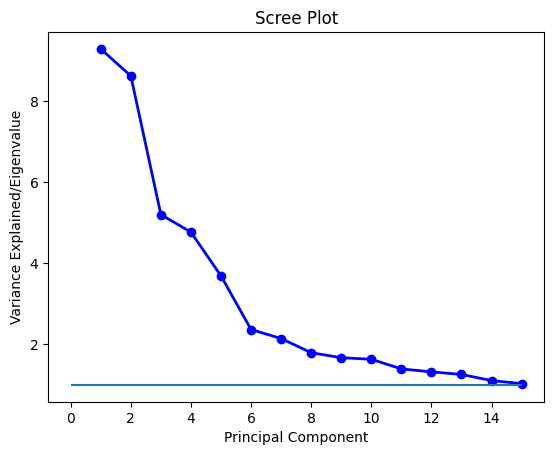

In [ ]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained/Eigenvalue')
plt.hlines(y=1, xmin=0, xmax=len(pca.explained_variance_))
plt.show()

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

pca_df = pd.DataFrame(data=loadings,
                      columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11'],
                      index=X.columns)
print(pca_df)
pca_df.to_excel('/content/drive/MyDrive/High and Low Context Files/Code/Run 3/chinese_pca_analysis.xlsx')

                            PC1       PC2       PC3       PC4       PC5  \
informativeness        0.136112  0.762560  0.210363  0.202981  0.129887   
constructive_feedback  0.295793  0.156802  0.509715 -0.112913 -0.073019   
author_revelation      0.097540 -0.491717  0.302433  0.267004 -0.058770   
comprehensibility      0.115758  0.324950  0.061209  0.047991 -0.468973   
detail_level           0.043579  0.532234  0.143966  0.404293  0.137089   
...                         ...       ...       ...       ...       ...   
context-first          0.319990  0.016964 -0.054097  0.314352  0.324191   
setting-first          0.167501  0.061709 -0.146163  0.397142  0.214994   
chronological          0.139509  0.070336 -0.272400  0.630241  0.090203   
transition_level       0.325982  0.121142  0.008544  0.502773  0.285096   
causal_level           0.284923  0.076998  0.322453  0.368800  0.341363   

                            PC6       PC7       PC8       PC9      PC10  \
informativeness        0

In [ ]:
pc1_df = pca_df[['PC1']]
pc1_df = pc1_df[(pc1_df['PC1'] <= -0.5) | (pc1_df['PC1'] >= 0.5)]
pc1_df

,PC1
supportiveness,0.776475
empathy,0.757872
group_harmony,0.704847
shared_responsibility,0.559194
group_wellbeing,0.502055
tactful,0.816851
critique,0.754649
conflict,0.779652
politeness,0.776019
directness,-0.577561


In [ ]:
pc2_df = pca_df[['PC2']]
pc2_df = pc2_df[(pc2_df['PC2'] <= -0.5) | (pc2_df['PC2'] >= 0.5)]
pc2_df

,PC2
informativeness,0.762560
detail_level,0.532234
explicitness,0.533564
implied_meaning,-0.546517
vividness,-0.501758
expressfulness,-0.713762
matter_of_factness,0.852880
formality,0.545874
emotionality,-0.791261
impersonality,0.655017


In [ ]:
pc3_df = pca_df[['PC3']]
pc3_df = pc3_df[(pc3_df['PC3'] <= -0.5) | (pc3_df['PC3'] >= 0.5)]
pc3_df

,PC3
constructive_feedback,0.509715
persuasiveness,0.785579
logical_reasoning,0.612251
right_wrong,0.661143
challenge,0.657374


In [ ]:
pc4_df = pca_df[['PC4']]
pc4_df = pc4_df[(pc4_df['PC4'] <= -0.5) | (pc4_df['PC4'] >= 0.5)]
pc4_df

,PC4
narrative,0.766539
narrative_mode,0.768432
storytelling,0.673339
chronological,0.630241
transition_level,0.502773


In [ ]:
pc5_df = pca_df[['PC5']]
pc5_df = pc5_df[(pc5_df['PC5'] <= -0.5) | (pc5_df['PC5'] >= 0.5)]
pc5_df

,PC5
abstractness,0.569524


# Human evaluation

In [ ]:
## Loading feature tables

## using non-normalized metadiscourse feature table for human evaluation - so that it is to count and verify correctness of LLM annotations
metadiscourseFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/output_metadiscourseFeatures_notNormalized.csv"
styleFeature_Table_path = "/content/drive/MyDrive/High and Low Context Files/Code/output_styleFeatures.csv"

df_metadiscourse = pd.read_csv(metadiscourseFeature_Table_path, index_col=0)
df_style = pd.read_csv(styleFeature_Table_path, index_col=0)

EmptyDataError: No columns to parse from file

In [ ]:
metadiscourseStyleFeatures_df = pd.merge(df_metadiscourse, df_style, on='message_id', how='inner')

In [ ]:
metadiscourseStyleFeatures_df.head()

In [ ]:
# set the number of samples for human evaluation
k =20
random_sample = metadiscourseStyleFeatures_df.sample(n=k, random_state=42)

In [ ]:
#set output file path to save output
human_evaluation_english_path = "/content/drive/MyDrive/High and Low Context Files/Code/human_evaluation_english.csv"
random_sample.to_csv(human_evaluation_english_path)

# DLATK analysis

#ARCHIVED PROMPTS

In [ ]:
## Run 1 for metadiscourse feature labeling (pre-addition of storytelling features and pre-removal of high correlates)
def extract_metadiscourseFeatures_english(post, temp):
  response = openai.chat.completions.create(
  model="chatgpt-4o-latest",
  messages=[
    {
  "role": "system",
  "content": "You are a linguistics expert that annotates metadiscourse markers in two to three sentence-long utterances."
    },
   {
      "role": "user",
      "content": f'''
      {{
      "task": "Annotate metadiscourse markers in two to three sentence-long utterances are.",
       "description": "Identify and label metadiscourse markers in the given text using angular brackets with the appropriate metadiscourse label. A word or symbol can be assigned more than one marker, in which case, all relevant markers should be enclosed in angular brackets sequentially. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>. DO NOT EXPLAIN YOUR ANSWERS",
  "categories": {{
    "interactive": {{
      "": {{
        "definition": "Words that express semantic relation between main clauses.",
        "examples": ["additionally", "again", "also", "although", "as a result","at the same time", "because", "but", "consequently", "conversely", "even", "even though", "furthermore", "however", "in addition", "in the same way", "nonetheless", "on the other hand", "once", "rather", "regard", "result in", "since", "so", "still", "then", "therefore", "though", "too", "while", "yet"]
      }},
      "frame_markers": {{
        "definition": "Words that refer to discourse acts, sequences, or text stages.",
        "examples": ["to begin with", "my point is", "add", "at this point", "at this stage", "back", "begin", "finally", "first", "first of all", "goal", "in regard to", "in short", "last", "next", "my advice is", "now", "purpose", "return to", "second", "subsequently", "third", "want to", "well", "would like to"]
      }},
      "endophoric_markers": {{
        "definition": "Words that refer to information from other parts of the text.",
        "examples": ["what I mentioned before", "the above", "above", "below", "first"]
      }},
      "evidentials": {{
        "definition": "Words that refer to a source of information from other texts.",
        "examples": ["as xxx once said", "according to xxx"]
      }},
      "code_glosses": {{
        "definition": "Words that help readers grasp meanings of ideational material.",
        "examples": ["such as", "for example", "that is", "I mean", "in fact", "in other words", "indeed", "say", "this means", "which means"]
      }}
    }},
    "interactional": {{
      "hedges": {{
        "definition": "Words that withhold the writer's full commitment to a proposition.",
        "examples": ["might", "could", "I'm not sure but", "likely", "a little", "about", "almost", "apparent", "apparently", "appear", "around", "assume", "believe", "certain", "claim", "could", "doubt", "fairly", "feel", "felt", "generally", "guess", "I think", "in general", "in most cases", "in my opinion", "in my view", "know", "largely", "likely", "may", "maybe", "might", "mostly", "often", "perhaps", "possible", "possibly", "presumably", "probably", "quite", "rather", "relatively", "seems", "should", "sometimes", "somewhat", "suspect", "tend to", "typically", "unlikely", "usually", "would"]
      }},
      "boosters": {{
        "definition": "Words that emphasize force or the writer's certainty in a proposition.",
        "examples": ["definitely", "certainly", "really", "in fact", "exclamation marks (!)", "actually", "always", "believe", "certain", "certainly", "clear", "clearly", "definitely", "found", "in fact", "indeed", "just", "know", "many", "must", "never", "obviously", "of course", "realize", "realized", "really", "shown", "shows", "specifically", "sure", "surely", "true", "truly", "undeniable"]
      }},
      "attitude_markers": {{
        "definition": "Words that express the writer's attitude to a proposition.",
        "examples": ["I agree", "unexpectedly", "agree", "amazing", "appropriate", "disappointed", "disappointing", "even", "expected", "fortunate", "fortunately", "hopeful", "hopefully", "important", "importantly", "inappropriate", "interesting", "interestingly", "prefer", "see", "surprisingly", "understandable", "understandably", "unexpected", "unfortunate", "unfortunately", "unusual", "usual"]
      }},
      "engagement_markers": {{
        "definition": "Words that explicitly refer to or build a relationship with the reader.",
        "examples": ["consider this", "you can see that", "have to", "question marks (?)", "by the way", "choose", "consider", "determine", "do not", "have to", "imagine", "incidentally", "key", "measure", "must", "need to", "note", "notice", "order", "our", "really", "recall", "remember", "see", "should", "think about", "think of", "us", "use", "we", "you", "your"]
      }},
      "self_mentions": {{
        "definition": "Words that indicate explicit reference to the author(s).",
        "examples": ["I", "we", "our", "me", "us", "my"]
      }}
    }},
    "other": {{
      "deontic_modal_words": {{
        "definition": "Words or word phrases that express concepts of obligation, permission, and prohibition, often in the context of what a person or agent is required, allowed, or forbidden to do.",
        "examples": ["should", "must", "ought to", "may", "can", "must not", "cannot", "have to", "I suggest", "got to"]
      }},
      "adverbs_of_degree": {{
        "definition": "Words that indicate the intensity, extent, or level of an action, adjective, or another adverb",
        "examples": ["very", "extremely", "highly", "incredibly", "positively", "quite", "fairly", "somewhat", "rather", "pretty", "barely", "slightly", "almost", "enough", "so", "completely", "too"]
      }},
      "idioms": {{
        "definition": "Phrases that are more than the sum of their parts, or in other words, have more of a meaning than the individual words used in the phrase. Additionally, also phrases that are particular to a geographical area that has specific vocabulary, syntax, and grammar.",
        "examples": ["pay the piper", "for the birds", "pulling one's leg", "9 shepherds for 10 sheep", "raining cats and dogs", "see the light", "break a leg", "break the ice", "beat around the bush", "cry over spilled milk", "cutting corners", "costs an arm and a leg", "under the weather", "spill the beans", "hit the nail on the head", "piece of cake"]
      }},
      "slang_and_colloquialisms": {{
        "definition": "Words or phrases commonly used in natural, highly informal, spoken conversations rather than in formal or literary writing, including ones popular in specific social groups.",
        "examples": ["going postal", "bogus", "adulting", "y'all", "what's up", "dope", "sus", "fixing to", "bruh", "feeling blue", "yeet", "bussin". "glow up", "slay", "wicked", "old fogey", "rizz", "gonna", "wanna", "brainrot", "clout", "cooked", "crash out", "delulu", "drip", "extra", "flex", "girl math", "glow-up", "GOAT", "let them cook", "irl", "mood"]
      }},
      "positive_connotations": {{
        "definition": "Words with emotional or cultural associations that goes beyond their literal meanings, with positive connotations evoke pleasant or favorable feelings and associations.",
        "examples": ["ambitious", "brave", "caring", "determined", "dazzling", "empowering", "eager", "flourishing", "generous", "meticulous", "spirited", "hopeful", "inquisitive", "heroic", "calm", "friendly", "quintessential", "vibrant", "youthful", "faithful", "eloquent"]
      }},
      "negative_connotations": {{
        "definition": "Words with unpleasant or unfavorable emotional associations or implied meanings, beyond their literal definitiona.",
        "examples": ["abrasive", "bleak", "clumsy", "dismal", "evasive", "frivolous", "gruesome", "harsh", "ignorant", "jaded", "knotty", "lethargic", "malicious", "nefarious", "obnoxious", "pernicious", "querelous", "repugnant", "sinister", "toxic", "unsettling", "vile", "warped", "xenophobic"]
      }},
      "explicit_references": {{
        "definition": "Words or phrases that point to a specific person, object, or idea in the real world or within a text, leaving no room for ambiguity or misinterpretation",
        "examples": ["I", "David", "Queen Elizabeth", "John went to the store. He bought groceries", "The sky is blue", "My sister likes candy", "Sam bought some cookies. She ate them all", "The tall man in the blue suit", "The manual explicitly states not to turn the computer off at this stage", "Since today is Monday, let's meet tomorrow on Tuesday", "Leave the package here with me"]
      }},
      "situation_dependent_references": {{
        "definition": "Linguistic expressions whose meaning depends on the specific context or situation of utterance, including the speaker, addressee, time, and location.",
        "examples": ["She dried off because Mary was wet", "They liked it so much they ordered more", "The kids were playing by the river bank", "The Mayor is giving a press conference in Philadelphia", "The Queen is currently speaking in Buckingham Palace", "Let's meet tomorrow", "Leave the package over there"]
      }},
      "figurative_language": {{
        "definition": "Words or phrases with a meaning that is different from their literal interpretation to create a special effect or convey a deeper meaning.",
        "examples": ["as bright as the sun", "the world is a stage", "the wind whispered", "as busy as a bee", "heart of stone", "time is money", "graceful like a gazelle", "you are my sunshine", "as blind as a bat", "as clear as crystal", "as dead as a doornail", "as cunning as a fox", "like a Garden of Eden", "told you a million times", "so hungry I could eat a horse", "weights a ton", "skinny as a toothpick", "faster than the wind"]
      }},
      "emotional_self_disclosures": {{
        "definition": "Words or phrases that share personal thoughts, feelings, and intense emotional experiences to the reader, moving beyond superficial information to reveal one's inner world.",
        "examples": ["I am unhappy", "I'm burnt out", "I freaked out", "I'm angry", "I've been worried", "I feel so alone", "I'm finding it hard", "made me feel terrified", "I'm ecstatic", "I'm bored", "I was super stoked", "I'm pissed off", "I can't stand it", "I'm exhausted", "I love this", "I'm going through a break-up", "I personally believe that", "I cannot wait"]
      }},
      "pleonasms": {{
        "definition": "Words or phrases that are redundant or repetitive and express the same idea rhetorically in the text.",
        "examples": ["tuna fish", "perhaps it's possible", "maybe it's possible", "tasty and delicious", "free, gratis, and for nothing", "free gift", "hot water heater", "pricey and expensive", "burning hot fire", "I don't see why not", "I saw it with my own eyes", "blended smoothie", "exact replica", "ice-cold drink"]
      }}
    }}
  }},
  "annotation_format": "Enclose identified metadiscourse markers in angular brackets following the word. If a word has multiple markers, all relevant labels should be included sequentially within the brackets. Do not include the categories (EX: other, interactional, interactive). If a marker is identified and marked with a set of brackets, DO NOT include another set of brackets like </ ... > after the word. DO NOT do this - <marker> word </marker>, and DO NOT do this - <marker> word <marker>. If there is a marker spotted, do this - word<marker>.",
  "example": {{
    "input": "Some guy tried to do the same thing with me once! He faked cancer for about a month, then one day, he “had a heart attack,” and told me the hospital he was admitted into. I called the hospital, and they had no record of him there. So I aggressively confronted the guy, he admitted he was lying about everything, and I told him he needed professional mental help. People who are THIS crazy are scary… they don’t know what’s right vs wrong.",
    "output": "Some guy tried to do the same thing with me<self-mentions> once!<boosters> He faked cancer for about a month, then<transitions> one day, he “had a heart attack,”<boosters> and told me<self-mentions> the hospital he was admitted into. I<self-mentions> called the hospital, and they had no record of him there. So I<self-mentions> aggressively confronted the guy, he admitted he was lying about everything, and I<self-mentions> told him he needed professional mental help. People who are THIS<boosters> crazy are scary… they don’t know what’s right vs wrong."
  }},
  "text": "{post}"
  }}
  '''
  }
  ],
  temperature=temp,
  max_tokens=1024,
  # gpt-5 only params: reasoning_effort
  # reasoning_effort="medium",
  # verbosity="low",
  top_p=1,
  frequency_penalty=0,
  presence_penalty=0
  )

  output = response.choices[0].message.content.strip()
  #print(output)

  return output

In [ ]:
## Run 1 for STYLE feature labeling (pre-addition of storytelling features and pre-removal of high correlates)
def extract_styleFeatures_english(post, temp):
    response = openai.chat.completions.create(
        model="chatgpt-4o-latest",
        messages=[
            {
                "role": "system",
                "content": "You are an AI assistant trained to evaluate and annotate advice given in social media posts based on various criteria. Rate each question on a scale from 1 (not at all) to 7 (very much), unless otherwise stated. Return the output in JSON format"
            },
            {
                "role": "user",
                "content": f'''
                {{
                    "task": "Annotate advice-related social media posts based on multiple linguistic and psychological dimensions.",
                    "description": "Rate each of the following questions on a scale of 1 (not at all) to 7 (very much). Select temporal orientation as past, present, or future. If multiple orientations apply, return all that apply.\
                    ALWAYS FOLLOW THE RATING SCALE OF 1 (not at all) TO 7 (very much) EXCEPT FOR TEMPORAL ORIENTATION. DO NOT EXPLAIN YOUR ANSWERS.\
                    ",
                    "criteria": {{
                        "informativeness": "How much does this advice provide information or solutions?",
                        "constructive_feedback": "How much does this advice offer constructive feedback?",
                        "criticality": "How much does this advice criticise?",
                        "self_disclosure": "How much self-disclosure is there in this advice?",
                        "author_revelation": "How much does this advice reveal about the author?",
                        "comprehensibility": "How easy is this advice to understand?",
                        "detail_level": "How detailed is this advice?",
                        "explicitness": "How explicit is this advice?",
                        "context_dependence": "How much additional context is needed to understand this advice?",
                        "persuasiveness": "How much does this advice attempt to persuade the reader of a point?",
                        "logical_reasoning": "How much does this advice emphasize logical reasoning?",
                        "anecdotal_reasoning": "How much does this advice rely on anecdotal or experiential reasoning?",
                        "right_wrong": "How much does this advice frame actions in terms of right and wrong?",
                        "tradition": "How much does this advice appeal to tradition or authority?",
                        "supportiveness": "How supportive is this advice?",
                        "empathy": "How empathetic is this advice?",
                        "status_suggestion": "How much does this advice suggest that the people are of different status?",
                        "status_appropriateness": "How appropriate is the advice for their status difference?",
                        "personal_choice": "How much does this advice emphasize personal choice?",
                        "independence": "How much does this advice emphasize independence?",
                        "group_harmony": "How much does this advice emphasize group harmony?",
                        "shared_responsibility": "How much does this advice emphasize shared responsibility?",
                        "self-reliance": "How much does this advice emphasize self-reliance?",
                        "cooperation": "How much does this advice promote cooperation?",
                        "group_wellbeing": "How much does this advice focus on group well-being?",
                        "self_growth": "How much does this advice emphasize self-growth?",
                        "self_responsibility": "How much does this advice place responsibility on the individual?",
                        "ext_responsibility": "How much does this advice place responsibility on external factors or others?",
                        "other_reliance": "How much does this advice emphasize relying on others?",
                        "maintain_relationship": "How much does this advice prioritize maintaining relationships?",
                        "accomplish_tasks": "How much does this advice prioritize accomplishing tasks?",
                        "implied_meaning": "How much does this advice imply meaning rather than state it?",
                        "creative_text": "How much does this advice use metaphors, analogies, or storytelling to convey its message?",
                        "repetitive": "How much does this advice repeat key ideas or phrases to enhance clarity?",
                        "point_faults": "How much does this advice avoid naming problems or pointing out faults directly?",
                        "tactful": "How tactful is this advice?",
                        "critique": "How much does this advice soften critique through indirect or roundabout language?",
                        "challenge": "How openly does this advice challenge assumptions, behaviors, or norms?",
                        "conflict": "How much does this advice downplay disagreement or conflict to maintain social harmony?",
                        "build_connection": "How much does this advice include personal anecdotes or experiences to build connection?",
                        "relational_1":"How much does this advice prioritize maintaining relationships?",
                        "orientation": "Which time period does this advice most focus on?",
                        "vividness": "How vivid is this utterance?",
                        "expressfulness": "How expressful is this utterance?",
                        "vagueness": "How vague is this utterance?",
                        "matter_of_factness": "How matter-of-fact is this utterance?",
                        "abstractness": "How abstract is this utterance?",
                        "figurativeness": "How figurative is this utterance?",
                        "concreteness": "How concrete is this utterance?",
                        "formality": "How formal is this utterance?",
                        "conciseness": "How concise is this utterance?",
                        "verbosity": "How verbose is this utterance?",
                        "emotionality": "How emotional is this utterance?",
                        "impersonality": "How impersonal is this utterance?",
                        "politeness": "How polite is this utterance?",
                        "directness": "How direct is this utterance?",
                        "bluntness": "How blunt is this utterance?",
                        "cultural-relatedness": "How much cultural knowledge does this utterance use?"
                    }},
                    "rating_scale": "For all questions (except temporal orientation), rate on a scale of 1 (not at all) to 7(very much or a lot)."
                }},
                "text": "{post}"
               }}
                '''
            }
        ],
        temperature=temp,
        max_tokens=1024,
        top_p=1,
        frequency_penalty=0,
        presence_penalty=0,
        response_format={"type": "json_object"}
    )

    output = response.choices[0].message.content.strip()
    return output